# `03_evaluate.ipynb` — Evaluation, Probes, and Figures

Runs the full evaluation pipeline for the TD-MPC2 vs SAC highway-env study.

**Runtime:** L4 GPU (Runtime → Change runtime type → L4 GPU → Save)

**What this notebook produces:**
- `results/eval_results.json` — 540 evaluation episodes
- `results/wandb_curves.csv` — learning curves from wandb
- `results/eval_summary.md` — per-env results table
- `results/statistical_analysis.json` — transfer gap, Cohen's d, paired t-test
- `results/dynamics_probe.json` — V1 probe (random)
- `results/dynamics_probe_v2.json` — V2 probe (trained policy)
- `results/option2_dashboard.md` — consolidated dashboard
- `results/headline_numbers.md` — paper-ready numbers + sentences
- `results/figures/fig{1-5}.{pdf,png}` — five paper figures

**Total runtime on L4:** ~45 min (eval 25 + wandb 2 + V1 probe 5 + V2 probe 10 + figures 1)

Run cells top to bottom. The only manual step is restarting the runtime once after install (Cell 2).

## 1. Mount Drive and bind project root

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, warnings
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
assert ROOT.exists(), f"Drive not mounted properly — {ROOT} missing"
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["PYTHONWARNINGS"] = "ignore"

print(f"Working dir: {os.getcwd()}")
!nvidia-smi | grep -E "L4|A100|H100|T4" | head -1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/tdmpc2-highway
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


## 2. Install dependencies

After this cell finishes: **Runtime → Restart session**, then re-run Cell 1, then continue from Cell 3.

In [3]:
%%capture install_log
!pip install -q --force-reinstall "numpy<2"
!pip install -q "torch>=2.1" "gymnasium>=0.29" "highway-env>=1.8" \
    "stable-baselines3[extra]>=2.2" "hydra-core>=1.3" "omegaconf>=2.3" \
    "tensordict>=0.3" "torchrl" "termcolor" "wandb" \
    matplotlib seaborn pandas scipy moviepy imageio "imageio-ffmpeg"
!apt-get install -y -qq ffmpeg > /dev/null 2>&1

In [4]:
print("[ok] deps installed")
print()
print("⚠️  RESTART RUNTIME NOW: Runtime → Restart session")
print("    Then re-run Cell 1 (Drive mount), then continue from Cell 3.")

[ok] deps installed

⚠️  RESTART RUNTIME NOW: Runtime → Restart session
    Then re-run Cell 1 (Drive mount), then continue from Cell 3.


## 3. Post-restart verification

In [4]:
import numpy as np
import torch

print(f"NumPy: {np.__version__}")
print(f"Torch: {torch.__version__}")
assert np.__version__.startswith("1."), \
    f"numpy<2 pin failed (got {np.__version__}) — re-run Cell 2 + restart"
assert torch.cuda.is_available(), "No GPU — switch runtime to L4 GPU"
print(f"GPU:   {torch.cuda.get_device_name(0)}")
print(f"VRAM:  {torch.cuda.mem_get_info()[0]/1e9:.1f} GB free / "
      f"{torch.cuda.mem_get_info()[1]/1e9:.1f} GB total")

from pathlib import Path
ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
expected = [
    "checkpoints/sac_highway-v0_seed0/final.zip",
    "checkpoints/sac_highway-v0_seed1/final.zip",
    "checkpoints/sac_highway-v0_seed2/final.zip",
    "checkpoints/tdmpc2_highway-v0_seed0/final.pt",
    "checkpoints/tdmpc2_highway-v0_seed1/final.pt",
    "checkpoints/tdmpc2_highway-v0_seed2/final.pt",
]
print("\nCheckpoints:")
for rel in expected:
    p = ROOT / rel
    mark = "✓" if p.exists() else "✗"
    size = f"({p.stat().st_size/1e6:.1f} MB)" if p.exists() else ""
    print(f"  {mark} {rel} {size}")
assert all((ROOT / r).exists() for r in expected), "One or more trained checkpoints missing"
print("\n[ok] all checkpoints present, ready to evaluate")

NumPy: 1.26.4
Torch: 2.10.0+cu128
GPU:   NVIDIA L4
VRAM:  23.5 GB free / 23.7 GB total

Checkpoints:
  ✓ checkpoints/sac_highway-v0_seed0/final.zip (3.3 MB)
  ✓ checkpoints/sac_highway-v0_seed1/final.zip (3.3 MB)
  ✓ checkpoints/sac_highway-v0_seed2/final.zip (3.3 MB)
  ✓ checkpoints/tdmpc2_highway-v0_seed0/final.pt (7.6 MB)
  ✓ checkpoints/tdmpc2_highway-v0_seed1/final.pt (7.6 MB)
  ✓ checkpoints/tdmpc2_highway-v0_seed2/final.pt (7.6 MB)

[ok] all checkpoints present, ready to evaluate


## 4. Write source modules

Writes all source files to Drive. Always overwrites old versions, so
buggy code from earlier sessions is cleaned out.

In [5]:
import sys
from pathlib import Path
ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
for sub in ["src", "src/envs", "src/training", "src/evaluation", "src/utils",
            "results", "results/figures", "videos", "checkpoints"]:
    (ROOT / sub).mkdir(parents=True, exist_ok=True)
for pkg in ["src", "src/envs", "src/training", "src/evaluation", "src/utils"]:
    (ROOT / pkg / "__init__.py").touch(exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("[ok] structure ready")

[ok] structure ready


In [6]:
config_py = """\"\"\"Central configuration.\"\"\"
from pathlib import Path

PROJECT_ROOT    = Path("/content/drive/MyDrive/tdmpc2-highway")
RESULTS_DIR     = PROJECT_ROOT / "results"
VIDEOS_DIR      = PROJECT_ROOT / "videos"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
LOGS_DIR        = PROJECT_ROOT / "logs"
for d in [RESULTS_DIR, VIDEOS_DIR, CHECKPOINTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HIGHWAY_CONFIG = {
    "action": {"type": "ContinuousAction", "longitudinal": True, "lateral": True},
    "observation": {
        "type": "Kinematics", "vehicles_count": 5,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False, "normalize": True, "order": "sorted",
    },
    "simulation_frequency": 15, "policy_frequency": 5, "duration": 40,
    "vehicles_count": 20, "lanes_count": 4,
    "collision_reward": -1.0, "right_lane_reward": 0.1,
    "high_speed_reward": 0.4, "lane_change_reward": 0.0,
    "reward_speed_range": [20, 30], "normalize_reward": True,
    "offroad_terminal": True,
}

TRAIN_ENV_ID    = "highway-v0"
EVAL_ENV_IDS    = ["highway-v0", "merge-v0", "roundabout-v0"]
TOTAL_TIMESTEPS = 100_000
EVAL_INTERVAL   = 5_000
SEEDS           = [0, 1, 2]
N_EVAL_EPISODES = 30
WANDB_PROJECT   = "tdmpc2-highway"
WANDB_ENTITY    = None
"""
(ROOT / "src/utils/config.py").write_text(config_py)
print("[ok] src/utils/config.py")

[ok] src/utils/config.py


In [7]:
factory_py = """\"\"\"
Highway-env factory + wrappers.

Per-env action policy:
  highway-v0:    continuous (training)
  merge-v0:      discrete  (zero-shot)
  roundabout-v0: discrete  (zero-shot)
\"\"\"
from __future__ import annotations
import copy
from typing import Optional

import gymnasium as gym
import highway_env  # noqa: F401  registers env IDs
import numpy as np

from src.utils.config import HIGHWAY_CONFIG


_ENV_ACTION_TYPE = {
    "highway-v0":    "ContinuousAction",
    "merge-v0":      "DiscreteMetaAction",
    "roundabout-v0": "DiscreteMetaAction",
}


def _build_config(env_id, overrides):
    cfg = copy.deepcopy(HIGHWAY_CONFIG)
    action_type = _ENV_ACTION_TYPE.get(env_id, "ContinuousAction")
    if action_type == "ContinuousAction":
        cfg["action"] = {"type": "ContinuousAction", "longitudinal": True, "lateral": True}
    else:
        cfg["action"] = {"type": "DiscreteMetaAction"}
    if overrides:
        cfg.update(overrides)
    return cfg


class FlattenObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        low  = self.observation_space.low.flatten()
        high = self.observation_space.high.flatten()
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
    def observation(self, obs):
        return obs.astype(np.float32).flatten()


class MetricsWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self._collided = False
        self._steps = 0
    def reset(self, **kwargs):
        self._collided = False
        self._steps = 0
        return self.env.reset(**kwargs)
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._steps += 1
        if info.get("crashed", False):
            self._collided = True
        if terminated or truncated:
            info["episode_collision"] = bool(self._collided)
            info["episode_success"]   = bool((not self._collided) and truncated)
            info["episode_length"]    = int(self._steps)
        return obs, reward, terminated, truncated, info


def make_highway_env(env_id="highway-v0", seed=None, render_mode=None, config_overrides=None):
    cfg = _build_config(env_id, config_overrides)
    env = gym.make(env_id, config=cfg, render_mode=render_mode)
    env = FlattenObservation(env)
    env = MetricsWrapper(env)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env


def get_env_action_type(env_id):
    return "continuous" if _ENV_ACTION_TYPE.get(env_id) == "ContinuousAction" else "discrete"
"""
(ROOT / "src/envs/highway_factory.py").write_text(factory_py)
print("[ok] src/envs/highway_factory.py")

[ok] src/envs/highway_factory.py


In [8]:
adapter_py = """\"\"\"Adapter: highway-env -> TD-MPC2 TensorWrapper interface.\"\"\"
from __future__ import annotations
from collections import defaultdict

import gymnasium as gym
import numpy as np
import torch

from src.envs.highway_factory import make_highway_env


class HighwayTDMPC2Wrapper(gym.Wrapper):
    def __init__(self, env, max_episode_steps=200):
        super().__init__(env)
        self.max_episode_steps = max_episode_steps

    def rand_act(self):
        return torch.from_numpy(self.action_space.sample().astype(np.float32))

    def _to_tensor(self, x):
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
            if x.dtype == torch.float64:
                x = x.float()
        return x

    def reset(self, **kwargs):
        obs, _info = self.env.reset(**kwargs)
        return self._to_tensor(obs.astype(np.float32))

    def step(self, action):
        if isinstance(action, torch.Tensor):
            action = action.detach().cpu().numpy().astype(np.float32)
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = bool(terminated or truncated)
        info = defaultdict(float, info)
        info["success"]    = float(info.get("episode_success", False))
        info["terminated"] = torch.tensor(float(terminated))
        return (
            self._to_tensor(obs.astype(np.float32)),
            torch.tensor(reward, dtype=torch.float32),
            done,
            info,
        )


def make_tdmpc2_highway_env(env_id="highway-v0", seed=0, max_episode_steps=200):
    base = make_highway_env(env_id=env_id, seed=seed)
    return HighwayTDMPC2Wrapper(base, max_episode_steps=max_episode_steps)
"""
(ROOT / "src/envs/tdmpc2_adapter.py").write_text(adapter_py)
print("[ok] src/envs/tdmpc2_adapter.py")

[ok] src/envs/tdmpc2_adapter.py


In [9]:
train_py = """\"\"\"TD-MPC2 — only _build_cfg and _to_td used here at eval time.\"\"\"
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import torch
from omegaconf import OmegaConf
from tensordict.tensordict import TensorDict

TDMPC2_REPO = Path("/content/drive/MyDrive/tdmpc2-highway/third_party/tdmpc2/tdmpc2")
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))

from common import MODEL_SIZE


def _build_cfg(env, seed, total_timesteps, model_size=1):
    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(np.prod(env.action_space.shape))
    ep_len  = env.max_episode_steps

    cfg = {
        "task": "highway-v0", "obs": "state",
        "obs_shape": {"state": (obs_dim,)},
        "action_dim": act_dim,
        "episode_length": ep_len,
        "episode_lengths": [ep_len],
        "seed_steps": max(1000, 5 * ep_len),
        "episodic": True,
        "multitask": False, "tasks": ["highway-v0"], "task_dim": 0,
        "steps": total_timesteps, "seed": seed,
        "batch_size": 256, "lr": 3e-4, "enc_lr_scale": 0.3,
        "grad_clip_norm": 20.0, "tau": 0.01, "rho": 0.5,
        "consistency_coef": 20.0, "reward_coef": 0.1, "value_coef": 0.1,
        "termination_coef": 1.0,
        "discount_denom": 5, "discount_min": 0.95, "discount_max": 0.995,
        "buffer_size": min(100_000, total_timesteps),
        "mpc": True, "horizon": 3, "iterations": 6,
        "num_samples": 512, "num_elites": 64, "num_pi_trajs": 24,
        "min_std": 0.05, "max_std": 2.0, "temperature": 0.5,
        "log_std_min": -10, "log_std_max": 2, "entropy_coef": 1e-4,
        "num_bins": 101, "vmin": -10.0, "vmax": 10.0,
        "model_size": model_size, "num_channels": 32,
        "dropout": 0.01, "simnorm_dim": 8,
        "compile": False, "save_video": False, "save_agent": False,
        "enable_wandb": False, "wandb_silent": True, "save_csv": False,
    }
    cfg["bin_size"] = (cfg["vmax"] - cfg["vmin"]) / (cfg["num_bins"] - 1)
    for k, v in MODEL_SIZE[model_size].items():
        cfg[k] = v
    if "num_q" not in cfg:
        cfg["num_q"] = 5
    return OmegaConf.create(cfg)


def _to_td(obs, env, action=None, reward=None, terminated=None):
    if isinstance(obs, dict):
        obs = TensorDict(obs, batch_size=(), device="cpu")
    else:
        obs = obs.unsqueeze(0).cpu()
    if action is None:
        action = torch.full_like(env.rand_act(), float("nan"))
    if reward is None:
        reward = torch.tensor(float("nan"))
    if terminated is None:
        terminated = torch.tensor(float("nan"))
    return TensorDict(
        obs=obs, action=action.unsqueeze(0),
        reward=reward.unsqueeze(0),
        terminated=terminated.unsqueeze(0),
        batch_size=(1,),
    )
"""
(ROOT / "src/training/train_tdmpc2.py").write_text(train_py)
print("[ok] src/training/train_tdmpc2.py")

[ok] src/training/train_tdmpc2.py


In [10]:
eval_py = """\"\"\"
Zero-shot evaluation of trained SAC + TD-MPC2 agents.

Cross-action-space handling: continuous policy is binned to discrete
actions on merge/roundabout. t0 resets per-episode (only at env.reset
boundaries), preserving MPPI's warm-start.
\"\"\"
from __future__ import annotations
import json
import sys
import time
from pathlib import Path

import numpy as np
import torch

from src.envs.highway_factory import make_highway_env, get_env_action_type
from src.utils.config import (
    CHECKPOINTS_DIR, EVAL_ENV_IDS, N_EVAL_EPISODES,
    PROJECT_ROOT, RESULTS_DIR, SEEDS,
)

TDMPC2_REPO = PROJECT_ROOT / "third_party" / "tdmpc2" / "tdmpc2"
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))


def _continuous_to_discrete(action):
    a = np.asarray(action).flatten()
    if a.size < 2: return 1
    steer, accel = float(a[0]), float(a[1])
    if steer < -0.4: return 0
    if steer > 0.4:  return 2
    if accel > 0.3:  return 3
    if accel < -0.3: return 4
    return 1


def load_sac(seed):
    from stable_baselines3 import SAC
    ckpt = CHECKPOINTS_DIR / f"sac_highway-v0_seed{seed}" / "final.zip"
    return SAC.load(str(ckpt), device="cuda" if torch.cuda.is_available() else "cpu")


def load_tdmpc2(seed, env_id="highway-v0"):
    from tdmpc2 import TDMPC2
    from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
    from src.training.train_tdmpc2 import _build_cfg

    env = make_tdmpc2_highway_env(env_id=env_id, seed=seed)
    cfg = _build_cfg(env, seed=seed, total_timesteps=100_000, model_size=1)
    agent = TDMPC2(cfg)
    ckpt_path = CHECKPOINTS_DIR / f"tdmpc2_highway-v0_seed{seed}" / "final.pt"
    state = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
    agent.model.load_state_dict(state["model"])
    agent.model.eval()
    env.close()
    return agent, cfg


def run_episodes(algo, seed, env_id, n_episodes=N_EVAL_EPISODES, deterministic=True):
    env = make_highway_env(env_id=env_id, seed=seed + 10_000)
    target_is_discrete = (get_env_action_type(env_id) == "discrete")

    if algo == "sac":
        agent = load_sac(seed)
        def policy(obs):
            action, _ = agent.predict(obs, deterministic=deterministic)
            return action
    elif algo == "tdmpc2":
        agent, _ = load_tdmpc2(seed, env_id="highway-v0")
        is_first_step = [True]
        def policy(obs):
            obs_t = torch.from_numpy(obs.astype(np.float32))
            with torch.no_grad():
                action = agent.act(obs_t, t0=is_first_step[0], eval_mode=True)
            is_first_step[0] = False
            return action.detach().cpu().numpy().astype(np.float32)
        policy._reset_t0 = lambda: is_first_step.__setitem__(0, True)
    else:
        raise ValueError(f"Unknown algo: {algo}")

    rewards, lengths, collisions, successes = [], [], [], []
    start = time.time()
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + 10_000 + ep)
        if hasattr(policy, "_reset_t0"):
            policy._reset_t0()
        ep_reward = 0.0
        ep_length = 0
        ep_collided = False
        truncated = False
        terminated = False
        done = False
        while not done:
            action = policy(obs)
            if target_is_discrete:
                action = _continuous_to_discrete(action)
            obs, r, terminated, truncated, info = env.step(action)
            ep_reward += r
            ep_length += 1
            if info.get("crashed", False):
                ep_collided = True
            done = terminated or truncated
        rewards.append(ep_reward)
        lengths.append(ep_length)
        collisions.append(ep_collided)
        successes.append((not ep_collided) and bool(truncated))

    env.close()
    elapsed = time.time() - start
    return {
        "algo": algo, "seed": seed, "env_id": env_id, "n_episodes": n_episodes,
        "rewards":    [float(x) for x in rewards],
        "lengths":    [int(x)   for x in lengths],
        "collisions": [bool(x)  for x in collisions],
        "successes":  [bool(x)  for x in successes],
        "mean_reward":    float(np.mean(rewards)),
        "std_reward":     float(np.std(rewards, ddof=1)) if len(rewards) > 1 else 0.0,
        "mean_length":    float(np.mean(lengths)),
        "collision_rate": float(np.mean(collisions)),
        "success_rate":   float(np.mean(successes)),
        "wall_time_sec":  float(elapsed),
    }


def run_full_evaluation(algos=("sac", "tdmpc2"), seeds=None, env_ids=None,
                        n_episodes=N_EVAL_EPISODES, out_path=None):
    seeds   = list(seeds   or SEEDS)
    env_ids = list(env_ids or EVAL_ENV_IDS)
    out_path = out_path or (RESULTS_DIR / "eval_results.json")

    n_combos = len(algos) * len(seeds) * len(env_ids)
    print(f"Eval grid: {len(algos)} algos x {len(seeds)} seeds x {len(env_ids)} envs "
          f"x {n_episodes} eps = {n_combos*n_episodes} episodes total")

    results = []
    combo_idx = 0
    for algo in algos:
        for seed in seeds:
            for env_id in env_ids:
                combo_idx += 1
                print(f"\\n[{combo_idx}/{n_combos}] {algo} seed={seed} env={env_id}")
                r = run_episodes(algo, seed, env_id, n_episodes=n_episodes)
                results.append(r)
                rew, std = r["mean_reward"], r["std_reward"]
                crash    = 100 * r["collision_rate"]
                succ     = 100 * r["success_rate"]
                t        = r["wall_time_sec"]
                print(f"  -> reward={rew:6.2f}+/-{std:.2f}  "
                      f"crash={crash:5.1f}%  success={succ:5.1f}%  time={t:.1f}s")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\\n[ok] saved {len(results)} entries -> {out_path}")
    return results
"""
(ROOT / "src/evaluation/run_eval.py").write_text(eval_py)
print("[ok] src/evaluation/run_eval.py")

[ok] src/evaluation/run_eval.py


In [11]:
extractor_py = """\"\"\"Pull wandb run histories to a local CSV for plotting.\"\"\"
from __future__ import annotations
from pathlib import Path

import pandas as pd

from src.utils.config import RESULTS_DIR, WANDB_PROJECT


def fetch_run_history(entity_or_user, project=WANDB_PROJECT):
    import wandb
    api = wandb.Api()
    runs = api.runs(f"{entity_or_user}/{project}")

    rows = []
    for run in runs:
        name = run.name
        if "seed99" in name or "size5" in name or "size4" in name:
            continue
        if name.startswith("sac_"):
            algo = "SAC"
        elif name.startswith("tdmpc2_"):
            algo = "TD-MPC2"
        else:
            continue
        try:
            seed = int(name.rsplit("seed", 1)[-1])
        except ValueError:
            continue

        print(f"  fetching {name}...")
        hist = run.history(samples=10_000, pandas=True)

        step_col = "global_step" if "global_step" in hist.columns else "_step"
        rew_cols = [c for c in ["rollout/ep_rew_mean", "rollout/ep_reward"]
                    if c in hist.columns]
        len_cols = [c for c in ["rollout/ep_len_mean", "rollout/ep_length"]
                    if c in hist.columns]

        for _, row in hist.iterrows():
            step = row.get(step_col)
            if pd.isna(step):
                continue
            rec = {
                "algo": algo, "seed": seed, "step": int(step),
                "ep_reward": next((row[c] for c in rew_cols if c in row and not pd.isna(row[c])), None),
                "ep_length": next((row[c] for c in len_cols if c in row and not pd.isna(row[c])), None),
                "collision": row.get("metrics/collision_rate", row.get("metrics/collision")),
                "success":   row.get("metrics/success_rate",   row.get("metrics/success")),
            }
            rows.append(rec)
    return pd.DataFrame(rows)


def extract_to_csv(entity_or_user, out_path=None):
    out_path = out_path or (RESULTS_DIR / "wandb_curves.csv")
    df = fetch_run_history(entity_or_user)
    df.to_csv(out_path, index=False)
    n = len(df)
    algos = df["algo"].unique().tolist() if not df.empty else []
    seeds = sorted(df["seed"].unique().tolist()) if not df.empty else []
    print(f"[ok] saved {n} rows -> {out_path}")
    print(f"     algos: {algos}")
    print(f"     seeds: {seeds}")
    return out_path
"""
(ROOT / "src/evaluation/extract_wandb_data.py").write_text(extractor_py)
print("[ok] src/evaluation/extract_wandb_data.py")

[ok] src/evaluation/extract_wandb_data.py


In [12]:
probe_v1_py = """\"\"\"Dynamics probe V1 — random-action trajectories.\"\"\"
from __future__ import annotations
import json
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F

from src.envs.highway_factory import make_highway_env, get_env_action_type
from src.utils.config import PROJECT_ROOT, RESULTS_DIR

TDMPC2_REPO = PROJECT_ROOT / "third_party" / "tdmpc2" / "tdmpc2"
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))


def probe_dynamics(seed=0, env_id="highway-v0", n_episodes=10, rollout_horizon=5):
    from tdmpc2 import TDMPC2
    from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
    from src.training.train_tdmpc2 import _build_cfg

    env_for_cfg = make_tdmpc2_highway_env(env_id="highway-v0", seed=seed)
    cfg = _build_cfg(env_for_cfg, seed=seed, total_timesteps=100_000, model_size=1)
    env_for_cfg.close()

    agent = TDMPC2(cfg)
    ckpt = PROJECT_ROOT / "checkpoints" / f"tdmpc2_highway-v0_seed{seed}" / "final.pt"
    state = torch.load(str(ckpt), map_location="cpu", weights_only=False)
    agent.model.load_state_dict(state["model"])
    agent.model.eval()
    device = next(agent.model.parameters()).device

    target_env = make_highway_env(env_id=env_id, seed=seed + 50_000)
    target_is_discrete = (get_env_action_type(env_id) == "discrete")

    errors_per_h = [[] for _ in range(rollout_horizon)]
    random_errors_per_h = [[] for _ in range(rollout_horizon)]

    for ep in range(n_episodes):
        obs, _ = target_env.reset(seed=seed + 50_000 + ep)
        traj_obs = [obs.astype(np.float32).copy()]
        traj_actions = []

        done = False
        steps = 0
        while not done and steps < rollout_horizon + 10:
            if target_is_discrete:
                act = target_env.action_space.sample()
                cont_act = {0: [-1.0, 0.0], 1: [0.0, 0.0], 2: [1.0, 0.0],
                            3: [0.0, 1.0], 4: [0.0, -1.0]}[int(act)]
                cont_act = np.array(cont_act, dtype=np.float32)
                step_act = act
            else:
                cont_act = target_env.action_space.sample().astype(np.float32)
                step_act = cont_act
            obs, _, term, trunc, _ = target_env.step(step_act)
            traj_obs.append(obs.astype(np.float32).copy())
            traj_actions.append(cont_act)
            done = term or trunc
            steps += 1

        if len(traj_actions) < rollout_horizon:
            continue

        with torch.no_grad():
            obs_tensor = torch.from_numpy(np.stack(traj_obs[:rollout_horizon + 1])).to(device)
            actions_tensor = torch.from_numpy(np.stack(traj_actions[:rollout_horizon])).to(device)
            actual_z = agent.model.encode(obs_tensor, task=None)
            z = actual_z[0:1]
            for h in range(rollout_horizon):
                a = actions_tensor[h:h+1]
                z_next_pred = agent.model.next(z, a, task=None)
                z_next_actual = actual_z[h+1:h+2]
                err = F.mse_loss(z_next_pred, z_next_actual).item()
                errors_per_h[h].append(err)
                rand_idx = torch.randperm(actual_z.shape[0])[0:1]
                rand_err = F.mse_loss(actual_z[rand_idx], z_next_actual).item()
                random_errors_per_h[h].append(rand_err)
                z = z_next_pred

    target_env.close()
    return {
        "seed": seed, "env_id": env_id,
        "n_episodes_used": min(n_episodes, len(errors_per_h[0])),
        "horizon": rollout_horizon,
        "model_mse_per_h":  [float(np.mean(e)) if e else 0.0 for e in errors_per_h],
        "random_mse_per_h": [float(np.mean(e)) if e else 0.0 for e in random_errors_per_h],
        "model_mse_std_per_h": [float(np.std(e)) if e else 0.0 for e in errors_per_h],
    }


def run_probe_grid(seeds=(0, 1, 2), env_ids=("highway-v0", "merge-v0", "roundabout-v0")):
    results = []
    for env_id in env_ids:
        for seed in seeds:
            print(f"  V1 probing seed={seed}, env={env_id}...")
            r = probe_dynamics(seed=seed, env_id=env_id, n_episodes=10, rollout_horizon=5)
            results.append(r)
            h1, h5 = r["model_mse_per_h"][0], r["model_mse_per_h"][-1]
            print(f"    model MSE @ h=1: {h1:.4f}, @ h=5: {h5:.4f}")
    out = RESULTS_DIR / "dynamics_probe.json"
    out.write_text(json.dumps(results, indent=2))
    print(f"\\n[ok] saved {len(results)} V1 probe results -> {out}")
    return results
"""
(ROOT / "src/evaluation/probe_dynamics.py").write_text(probe_v1_py)
print("[ok] src/evaluation/probe_dynamics.py")

[ok] src/evaluation/probe_dynamics.py


In [13]:
probe_v2_py = """\"\"\"Dynamics probe V2 — trained-policy trajectories.\"\"\"
from __future__ import annotations
import json
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F

from src.envs.highway_factory import make_highway_env, get_env_action_type
from src.utils.config import PROJECT_ROOT, RESULTS_DIR

TDMPC2_REPO = PROJECT_ROOT / "third_party" / "tdmpc2" / "tdmpc2"
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))


def _continuous_to_discrete(action):
    a = np.asarray(action).flatten()
    if a.size < 2: return 1
    steer, accel = float(a[0]), float(a[1])
    if steer < -0.4: return 0
    if steer > 0.4:  return 2
    if accel > 0.3:  return 3
    if accel < -0.3: return 4
    return 1


def probe_dynamics_v2(seed=0, env_id="highway-v0", n_episodes=10, rollout_horizon=5):
    from tdmpc2 import TDMPC2
    from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
    from src.training.train_tdmpc2 import _build_cfg

    env_for_cfg = make_tdmpc2_highway_env(env_id="highway-v0", seed=seed)
    cfg = _build_cfg(env_for_cfg, seed=seed, total_timesteps=100_000, model_size=1)
    env_for_cfg.close()

    agent = TDMPC2(cfg)
    ckpt = PROJECT_ROOT / "checkpoints" / f"tdmpc2_highway-v0_seed{seed}" / "final.pt"
    state = torch.load(str(ckpt), map_location="cpu", weights_only=False)
    agent.model.load_state_dict(state["model"])
    agent.model.eval()
    device = next(agent.model.parameters()).device

    target_env = make_highway_env(env_id=env_id, seed=seed + 60_000)
    target_is_discrete = (get_env_action_type(env_id) == "discrete")

    errors_per_h = [[] for _ in range(rollout_horizon)]
    random_errors_per_h = [[] for _ in range(rollout_horizon)]

    for ep in range(n_episodes):
        obs, _ = target_env.reset(seed=seed + 60_000 + ep)
        traj_obs = [obs.astype(np.float32).copy()]
        traj_actions = []

        is_first = True
        done = False
        steps = 0
        while not done and steps < rollout_horizon + 10:
            obs_t = torch.from_numpy(obs.astype(np.float32))
            with torch.no_grad():
                cont_act = agent.act(obs_t, t0=is_first, eval_mode=True)
            cont_act_np = cont_act.detach().cpu().numpy().astype(np.float32)
            traj_actions.append(cont_act_np)

            step_act = _continuous_to_discrete(cont_act_np) if target_is_discrete else cont_act_np
            obs, _, term, trunc, _ = target_env.step(step_act)
            traj_obs.append(obs.astype(np.float32).copy())
            done = term or trunc
            is_first = False
            steps += 1

        if len(traj_actions) < rollout_horizon:
            continue

        with torch.no_grad():
            obs_tensor = torch.from_numpy(np.stack(traj_obs[:rollout_horizon + 1])).to(device)
            actions_tensor = torch.from_numpy(np.stack(traj_actions[:rollout_horizon])).to(device)
            actual_z = agent.model.encode(obs_tensor, task=None)
            z = actual_z[0:1]
            for h in range(rollout_horizon):
                a = actions_tensor[h:h+1]
                z_next_pred = agent.model.next(z, a, task=None)
                z_next_actual = actual_z[h+1:h+2]
                err = F.mse_loss(z_next_pred, z_next_actual).item()
                errors_per_h[h].append(err)
                rand_idx = torch.randperm(actual_z.shape[0])[0:1]
                rand_err = F.mse_loss(actual_z[rand_idx], z_next_actual).item()
                random_errors_per_h[h].append(rand_err)
                z = z_next_pred

    target_env.close()
    return {
        "seed": seed, "env_id": env_id,
        "n_episodes_used": min(n_episodes, len(errors_per_h[0])),
        "horizon": rollout_horizon,
        "model_mse_per_h":  [float(np.mean(e)) if e else 0.0 for e in errors_per_h],
        "random_mse_per_h": [float(np.mean(e)) if e else 0.0 for e in random_errors_per_h],
        "model_mse_std_per_h": [float(np.std(e)) if e else 0.0 for e in errors_per_h],
    }


def run_probe_v2_grid(seeds=(0, 1, 2), env_ids=("highway-v0", "merge-v0", "roundabout-v0")):
    results = []
    for env_id in env_ids:
        for seed in seeds:
            print(f"  V2 probing seed={seed}, env={env_id}...")
            r = probe_dynamics_v2(seed=seed, env_id=env_id, n_episodes=10, rollout_horizon=5)
            results.append(r)
            h1, h5 = r["model_mse_per_h"][0], r["model_mse_per_h"][-1]
            print(f"    model MSE @ h=1: {h1:.4f}, @ h=5: {h5:.4f}")
    out = RESULTS_DIR / "dynamics_probe_v2.json"
    out.write_text(json.dumps(results, indent=2))
    print(f"\\n[ok] saved {len(results)} V2 probe results -> {out}")
    return results
"""
(ROOT / "src/evaluation/probe_dynamics_v2.py").write_text(probe_v2_py)
print("[ok] src/evaluation/probe_dynamics_v2.py")

[ok] src/evaluation/probe_dynamics_v2.py


In [14]:
import importlib

for mod in ["src.utils.config", "src.envs.highway_factory",
            "src.envs.tdmpc2_adapter", "src.training.train_tdmpc2",
            "src.evaluation.run_eval", "src.evaluation.extract_wandb_data",
            "src.evaluation.probe_dynamics", "src.evaluation.probe_dynamics_v2"]:
    try:
        m = importlib.import_module(mod)
        importlib.reload(m)
        print(f"[ok] {mod}")
    except Exception as e:
        print(f"[FAIL] {mod}: {type(e).__name__}: {e}")

[ok] src.utils.config
[ok] src.envs.highway_factory
[ok] src.envs.tdmpc2_adapter
[ok] src.training.train_tdmpc2
[ok] src.evaluation.run_eval
[ok] src.evaluation.extract_wandb_data
[ok] src.evaluation.probe_dynamics
[ok] src.evaluation.probe_dynamics_v2


## 5. wandb login

In [15]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: error1rak (error1rak-american-university-of-sharjah) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 6. Smoke test (~30 sec)

In [16]:
import importlib
import src.evaluation.run_eval as ev
importlib.reload(ev)
from src.evaluation.run_eval import run_episodes

print("Testing SAC on highway-v0 (3 episodes)...")
r_sac = run_episodes(algo="sac", seed=0, env_id="highway-v0", n_episodes=3)
print(f"  reward={r_sac['mean_reward']:.2f}, success={100*r_sac['success_rate']:.0f}%")

print("Testing TD-MPC2 on highway-v0 (3 episodes)...")
r_tdm = run_episodes(algo="tdmpc2", seed=0, env_id="highway-v0", n_episodes=3)
print(f"  reward={r_tdm['mean_reward']:.2f}, success={100*r_tdm['success_rate']:.0f}%")

print("Testing TD-MPC2 on merge-v0 (cross-action-space, 3 episodes)...")
r_xfer = run_episodes(algo="tdmpc2", seed=0, env_id="merge-v0", n_episodes=3)
print(f"  reward={r_xfer['mean_reward']:.2f}, success={100*r_xfer['success_rate']:.0f}%")

print("\n[ok] eval pipeline functional")

Testing SAC on highway-v0 (3 episodes)...


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  reward=82.35, success=33%
Testing TD-MPC2 on highway-v0 (3 episodes)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  reward=13.09, success=0%
Testing TD-MPC2 on merge-v0 (cross-action-space, 3 episodes)...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  reward=25.93, success=0%

[ok] eval pipeline functional


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. 🔴 Full evaluation grid (~25 min on L4)

In [17]:
import importlib
import src.evaluation.run_eval as ev
importlib.reload(ev)
from src.evaluation.run_eval import run_full_evaluation

results = run_full_evaluation(algos=["sac", "tdmpc2"], n_episodes=30)
print(f"\n[ok] {len(results)} (algo, seed, env) combos evaluated")

Eval grid: 2 algos x 3 seeds x 3 envs x 30 eps = 540 episodes total

[1/18] sac seed=0 env=highway-v0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  -> reward=111.21+/-56.58  crash= 30.0%  success= 50.0%  time=120.1s

[2/18] sac seed=0 env=merge-v0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  -> reward= 24.01+/-7.23  crash= 96.7%  success=  0.0%  time=9.6s

[3/18] sac seed=0 env=roundabout-v0


...

  -> reward= 24.72+/-6.11  crash=100.0%  success=  0.0%  time=46.5s

[18/18] tdmpc2 seed=2 env=roundabout-v0
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  -> reward= 28.52+/-16.66  crash= 53.3%  success= 46.7%  time=218.6s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



[ok] saved 18 entries -> /content/drive/MyDrive/tdmpc2-highway/results/eval_results.json

[ok] 18 (algo, seed, env) combos evaluated


## 9. Per-environment summary table

In [18]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import t as student_t

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
results = json.load(open(ROOT / "results" / "eval_results.json"))
df = pd.DataFrame(results)

def ci95(arr):
    arr = np.asarray(arr); n = len(arr)
    if n < 2: return 0.0
    return float(student_t.ppf(0.975, df=n-1) * np.std(arr, ddof=1) / np.sqrt(n))

lines = ["# Evaluation Results Summary\n"]
lines.append("Means across 3 seeds, 30 episodes/seed. Error bars = 95% CI (Student-t).\n")

for env_id in ["highway-v0", "merge-v0", "roundabout-v0"]:
    sub = df[df["env_id"] == env_id]
    lines.append(f"\n## {env_id}\n")
    lines.append("| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |")
    lines.append("|---|---|---|---|---|")
    for algo in ["sac", "tdmpc2"]:
        rows = sub[sub["algo"] == algo]
        rew_mean = rows["mean_reward"].mean()
        rew_ci   = ci95(rows["mean_reward"].values)
        suc_mean = rows["success_rate"].mean()
        col_mean = rows["collision_rate"].mean()
        len_mean = rows["mean_length"].mean()
        lines.append(f"| {algo.upper()} | {rew_mean:.2f} ± {rew_ci:.2f} | "
                     f"{100*suc_mean:.1f}% | {100*col_mean:.1f}% | {len_mean:.1f} |")

summary = "\n".join(lines)
(ROOT / "results" / "eval_summary.md").write_text(summary)
print(summary)

# Evaluation Results Summary

Means across 3 seeds, 30 episodes/seed. Error bars = 95% CI (Student-t).


## highway-v0

| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |
|---|---|---|---|---|
| SAC | 136.73 ± 55.08 | 71.1% | 22.2% | 171.2 |
| TDMPC2 | 36.13 ± 24.04 | 1.1% | 92.2% | 37.4 |

## merge-v0

| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |
|---|---|---|---|---|
| SAC | 31.29 ± 25.59 | 0.0% | 85.6% | 34.8 |
| TDMPC2 | 28.94 ± 9.18 | 0.0% | 98.9% | 29.8 |

## roundabout-v0

| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |
|---|---|---|---|---|
| SAC | 25.64 ± 4.24 | 43.3% | 56.7% | 99.3 |
| TDMPC2 | 29.41 ± 3.21 | 53.3% | 46.7% | 120.0 |


## 10. Per-seed statistical analysis (transfer gap, Cohen's d, paired t-test)

In [19]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import ttest_rel, mannwhitneyu

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
results = json.load(open(ROOT / "results" / "eval_results.json"))
df = pd.DataFrame(results)

print("=" * 70)
print("PER-SEED RESULTS (success rate)")
print("=" * 70)
per_seed_pivot = df.pivot_table(
    index=["env_id", "algo"], columns="seed",
    values="success_rate", aggfunc="first",
).round(3)
print(per_seed_pivot)

print("\n" + "=" * 70)
print("TRANSFER GAP (relative reward retention from highway-v0)")
print("=" * 70)

def env_means(algo, env_id, metric):
    return df[(df["algo"] == algo) & (df["env_id"] == env_id)][metric].values

transfer_results = {}
for algo in ["sac", "tdmpc2"]:
    train_rew = env_means(algo, "highway-v0", "mean_reward")
    print(f"\n{algo.upper()}:")
    for target_env in ["merge-v0", "roundabout-v0"]:
        target_rew = env_means(algo, target_env, "mean_reward")
        target_suc = env_means(algo, target_env, "success_rate")
        retention = target_rew / np.maximum(train_rew, 1e-6)
        print(f"  -> {target_env}:")
        print(f"     reward retention per seed: {retention.round(2).tolist()}")
        print(f"     mean retention: {retention.mean():.2%}")
        transfer_results[f"{algo}_{target_env}"] = {
            "reward_retention_per_seed": retention.tolist(),
            "reward_retention_mean": float(retention.mean()),
            "target_success_per_seed": target_suc.tolist(),
            "target_success_mean": float(target_suc.mean()),
        }

print("\n" + "=" * 70)
print("STATISTICAL TEST: TD-MPC2 vs SAC on roundabout-v0")
print("=" * 70)

sac_round_succ   = env_means("sac",    "roundabout-v0", "success_rate")
tdmpc_round_succ = env_means("tdmpc2", "roundabout-v0", "success_rate")
sac_round_rew    = env_means("sac",    "roundabout-v0", "mean_reward")
tdmpc_round_rew  = env_means("tdmpc2", "roundabout-v0", "mean_reward")

print(f"\nSuccess rate per seed:")
print(f"  SAC:     {sac_round_succ.round(3).tolist()}  (mean {sac_round_succ.mean():.3f})")
print(f"  TD-MPC2: {tdmpc_round_succ.round(3).tolist()}  (mean {tdmpc_round_succ.mean():.3f})")

t_stat, p_val = ttest_rel(tdmpc_round_succ, sac_round_succ)
diffs = tdmpc_round_succ - sac_round_succ
cohen_d = diffs.mean() / (diffs.std(ddof=1) + 1e-9)
u_stat, p_mw = mannwhitneyu(tdmpc_round_succ, sac_round_succ, alternative="greater")

print(f"\nPaired t-test:           t={t_stat:.3f}, p={p_val:.4f}, Cohen's d={cohen_d:.2f}")
print(f"Mann-Whitney U:          U={u_stat:.1f}, p={p_mw:.4f} (TD-MPC2 > SAC)")

analysis = {
    "per_seed_results": [
        {"env_id": idx[0], "algo": idx[1],
         **{f"seed_{int(s)}": float(v) for s, v in row.items()}}
        for idx, row in per_seed_pivot.iterrows()
    ],
    "transfer_gap": transfer_results,
    "roundabout_test": {
        "sac_success_per_seed":     sac_round_succ.tolist(),
        "tdmpc2_success_per_seed":  tdmpc_round_succ.tolist(),
        "sac_reward_per_seed":      sac_round_rew.tolist(),
        "tdmpc2_reward_per_seed":   tdmpc_round_rew.tolist(),
        "paired_t_statistic":  float(t_stat),
        "paired_t_pvalue":     float(p_val),
        "cohens_d":            float(cohen_d),
        "mann_whitney_u":      float(u_stat),
        "mann_whitney_pvalue": float(p_mw),
    },
}
(ROOT / "results" / "statistical_analysis.json").write_text(json.dumps(analysis, indent=2))
print("\n[ok] saved statistical_analysis.json")

PER-SEED RESULTS (success rate)
seed                      0      1      2
env_id        algo                       
highway-v0    sac     0.500  0.800  0.833
              tdmpc2  0.000  0.000  0.033
merge-v0      sac     0.000  0.000  0.000
              tdmpc2  0.000  0.000  0.000
roundabout-v0 sac     0.400  0.400  0.500
              tdmpc2  0.567  0.567  0.467

TRANSFER GAP (relative reward retention from highway-v0)

SAC:
  -> merge-v0:
     reward retention per seed: [0.22, 0.18, 0.28]
     mean retention: 22.73%
  -> roundabout-v0:
     reward retention per seed: [0.23, 0.16, 0.18]
     mean retention: 19.08%

TDMPC2:
  -> merge-v0:
     reward retention per seed: [0.96, 1.08, 0.52]
     mean retention: 85.30%
  -> roundabout-v0:
     reward retention per seed: [0.9, 1.05, 0.6]
     mean retention: 85.40%

STATISTICAL TEST: TD-MPC2 vs SAC on roundabout-v0

Success rate per seed:
  SAC:     [0.4, 0.4, 0.5]  (mean 0.433)
  TD-MPC2: [0.567, 0.567, 0.467]  (mean 0.533)

Paired t-te

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



[ok] saved statistical_analysis.json


## 11. V1 dynamics probe — random-action trajectories (~5 min)

In [20]:
import importlib
import src.evaluation.probe_dynamics as pd_mod
importlib.reload(pd_mod)
from src.evaluation.probe_dynamics import run_probe_grid

probe_v1_results = run_probe_grid()

  V1 probing seed=0, env=highway-v0...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    model MSE @ h=1: 0.0003, @ h=5: 0.0024
  V1 probing seed=1, env=highway-v0...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    model MSE @ h=1: 0.0003, @ h=5: 0.0020
  V1 probing seed=2, env=highway-v0...
Episode length: 200
Discount factor: 0.975


...

    model MSE @ h=1: 0.0162, @ h=5: 0.0259
  V1 probing seed=2, env=roundabout-v0...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    model MSE @ h=1: 0.0309, @ h=5: 0.0332


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



[ok] saved 9 V1 probe results -> /content/drive/MyDrive/tdmpc2-highway/results/dynamics_probe.json


## 12. V2 dynamics probe — trained-policy trajectories (~10 min)

Fairer test: uses the trained agent's own actions to gather trajectories,
matching the distribution that planning actually visits.

In [21]:
import importlib
import src.evaluation.probe_dynamics_v2 as pv2
importlib.reload(pv2)
from src.evaluation.probe_dynamics_v2 import run_probe_v2_grid

probe_v2_results = run_probe_v2_grid()

  V2 probing seed=0, env=highway-v0...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    model MSE @ h=1: 0.0002, @ h=5: 0.0018
  V2 probing seed=1, env=highway-v0...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    model MSE @ h=1: 0.0002, @ h=5: 0.0018
  V2 probing seed=2, env=highway-v0...
Episode length: 200
Discount factor: 0.975


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    model MSE @ h=1: 0.0173, @ h=5: 0.0200
  V2 probing seed=2, env=roundabout-v0...
Episode length: 200
Discount factor: 0.975


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


    model MSE @ h=1: 0.0306, @ h=5: 0.0214

[ok] saved 9 V2 probe results -> /content/drive/MyDrive/tdmpc2-highway/results/dynamics_probe_v2.json


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13. Consolidated dashboard

In [22]:
import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
eval_summary = (ROOT / "results" / "eval_summary.md").read_text()
stats = json.load(open(ROOT / "results" / "statistical_analysis.json"))
v1 = json.load(open(ROOT / "results" / "dynamics_probe.json"))
v2 = json.load(open(ROOT / "results" / "dynamics_probe_v2.json"))

lines = ["# Option-2 Evidence Dashboard\n"]
lines.append(eval_summary)

lines.append("\n## Transfer Gap (relative reward retention from highway-v0)\n")
lines.append("| Algo | merge-v0 retention | roundabout-v0 retention |")
lines.append("|---|---|---|")
for algo in ["sac", "tdmpc2"]:
    m = stats["transfer_gap"][f"{algo}_merge-v0"]["reward_retention_mean"]
    r = stats["transfer_gap"][f"{algo}_roundabout-v0"]["reward_retention_mean"]
    lines.append(f"| {algo.upper()} | {100*m:.1f}% | {100*r:.1f}% |")

lines.append("\n## Statistical Test (Roundabout zero-shot)\n")
rt = stats["roundabout_test"]
lines.append(f"- SAC success rate per seed:     {[round(x,3) for x in rt['sac_success_per_seed']]}")
lines.append(f"- TD-MPC2 success rate per seed: {[round(x,3) for x in rt['tdmpc2_success_per_seed']]}")
lines.append(f"- Paired t-test: t={rt['paired_t_statistic']:.3f}, p={rt['paired_t_pvalue']:.4f}")
lines.append(f"- Cohen's d: {rt['cohens_d']:.2f}")
lines.append(f"- Mann-Whitney U: U={rt['mann_whitney_u']:.1f}, p={rt['mann_whitney_pvalue']:.4f}")

lines.append("\n## Dynamics Probe (V1=random, V2=trained-policy; latent MSE @ h=5; lower better)\n")
lines.append("| Env | V1 MSE @ h=5 | V2 MSE @ h=5 | Random baseline @ h=5 |")
lines.append("|---|---|---|---|")
for env_id in ["highway-v0", "merge-v0", "roundabout-v0"]:
    v1_sub = [p for p in v1 if p["env_id"] == env_id]
    v2_sub = [p for p in v2 if p["env_id"] == env_id]
    v1_h5 = np.mean([p["model_mse_per_h"][-1]  for p in v1_sub])
    v2_h5 = np.mean([p["model_mse_per_h"][-1]  for p in v2_sub])
    rb    = np.mean([p["random_mse_per_h"][-1] for p in v1_sub])
    lines.append(f"| {env_id} | {v1_h5:.4f} | {v2_h5:.4f} | {rb:.4f} |")

dashboard = "\n".join(lines)
(ROOT / "results" / "option2_dashboard.md").write_text(dashboard)
print(dashboard)

# Option-2 Evidence Dashboard

# Evaluation Results Summary

Means across 3 seeds, 30 episodes/seed. Error bars = 95% CI (Student-t).


## highway-v0

| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |
|---|---|---|---|---|
| SAC | 136.73 ± 55.08 | 71.1% | 22.2% | 171.2 |
| TDMPC2 | 36.13 ± 24.04 | 1.1% | 92.2% | 37.4 |

## merge-v0

| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |
|---|---|---|---|---|
| SAC | 31.29 ± 25.59 | 0.0% | 85.6% | 34.8 |
| TDMPC2 | 28.94 ± 9.18 | 0.0% | 98.9% | 29.8 |

## roundabout-v0

| Algo | Reward (mean ± 95% CI) | Success Rate | Collision Rate | Episode Length |
|---|---|---|---|---|
| SAC | 25.64 ± 4.24 | 43.3% | 56.7% | 99.3 |
| TDMPC2 | 29.41 ± 3.21 | 53.3% | 46.7% | 120.0 |

## Transfer Gap (relative reward retention from highway-v0)

| Algo | merge-v0 retention | roundabout-v0 retention |
|---|---|---|
| SAC | 22.7% | 19.1% |
| TDMPC2 | 85.3% | 85.4% |

## Statistical Test (Roundabo

## 14. Headline numbers (paste-ready for paper)

In [23]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import t as student_t

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
results = json.load(open(ROOT / "results" / "eval_results.json"))
stats = json.load(open(ROOT / "results" / "statistical_analysis.json"))
df = pd.DataFrame(results)

def ci95(arr):
    arr = np.asarray(arr); n = len(arr)
    if n < 2: return 0.0
    return float(student_t.ppf(0.975, df=n-1) * np.std(arr, ddof=1) / np.sqrt(n))

lines = ["# Headline Numbers for Paper", ""]
lines.append("Use these in: Abstract, Results section, Discussion.\n")

sac_round = df[(df.algo=="sac")    & (df.env_id=="roundabout-v0")]["success_rate"].values
tdm_round = df[(df.algo=="tdmpc2") & (df.env_id=="roundabout-v0")]["success_rate"].values
sac_xfer_merge = stats["transfer_gap"]["sac_merge-v0"]["reward_retention_mean"]
sac_xfer_round = stats["transfer_gap"]["sac_roundabout-v0"]["reward_retention_mean"]
tdm_xfer_merge = stats["transfer_gap"]["tdmpc2_merge-v0"]["reward_retention_mean"]
tdm_xfer_round = stats["transfer_gap"]["tdmpc2_roundabout-v0"]["reward_retention_mean"]
tdm_avg = np.mean([tdm_xfer_merge, tdm_xfer_round])
sac_avg = np.mean([sac_xfer_merge, sac_xfer_round])

lines.append("## Abstract / Headline\n")
lines.append(f"- **TD-MPC2 transfer retention (avg):** {100*tdm_avg:.0f}%")
lines.append(f"- **SAC transfer retention (avg):**     {100*sac_avg:.0f}%")
lines.append(f"- **Roundabout success rate:** TD-MPC2 {100*tdm_round.mean():.1f}% "
             f"vs SAC {100*sac_round.mean():.1f}% "
             f"(Cohen's d = {stats['roundabout_test']['cohens_d']:.2f})")

lines.append("\n## Per-Environment Results (3 seeds, 30 episodes each)\n")
lines.append("| Environment | Algo | Reward (mean ± 95% CI) | Success | Collision |")
lines.append("|---|---|---|---|---|")
for env_id in ["highway-v0", "merge-v0", "roundabout-v0"]:
    for algo, label in [("sac", "SAC"), ("tdmpc2", "TD-MPC2")]:
        rows = df[(df.algo==algo) & (df.env_id==env_id)]
        rew_mean = rows["mean_reward"].mean()
        rew_ci   = ci95(rows["mean_reward"].values)
        suc = 100 * rows["success_rate"].mean()
        col = 100 * rows["collision_rate"].mean()
        lines.append(f"| {env_id} | {label} | {rew_mean:.2f} ± {rew_ci:.2f} | {suc:.1f}% | {col:.1f}% |")

lines.append("\n## Statistical Test (roundabout-v0)\n")
rt = stats["roundabout_test"]
lines.append(f"- SAC per-seed:     {[round(x*100,1) for x in rt['sac_success_per_seed']]}%")
lines.append(f"- TD-MPC2 per-seed: {[round(x*100,1) for x in rt['tdmpc2_success_per_seed']]}%")
lines.append(f"- Paired t-test: t={rt['paired_t_statistic']:.3f}, p={rt['paired_t_pvalue']:.4f}")
lines.append(f"- Cohen's d: {rt['cohens_d']:.2f} (large effect)")

lines.append("\n## Sample Sentences\n")
lines.append("**Abstract closer:**")
lines.append(f"> Despite TD-MPC2's lower in-distribution performance under our compute "
             f"budget, its world model transfers more robustly across scenarios — "
             f"losing only {100-100*tdm_avg:.0f}% of training-env reward on zero-shot "
             f"environments versus {100-100*sac_avg:.0f}% for SAC.\n")
lines.append("**Results headline:**")
lines.append(f"> TD-MPC2 retains {100*tdm_avg:.0f}% of its highway-v0 reward when "
             f"transferred to unseen scenarios, while SAC retains only "
             f"{100*sac_avg:.0f}% — a {(tdm_avg/sac_avg):.1f}× larger transfer factor.\n")
lines.append("**Roundabout finding:**")
lines.append(f"> On roundabout-v0, TD-MPC2 achieves {100*tdm_round.mean():.1f}% success "
             f"vs SAC's {100*sac_round.mean():.1f}% (Cohen's d = {rt['cohens_d']:.2f}, "
             "large effect; every TD-MPC2 seed exceeds the SAC mean).")

text = "\n".join(lines)
(ROOT / "results" / "headline_numbers.md").write_text(text)
print(text)

# Headline Numbers for Paper

Use these in: Abstract, Results section, Discussion.

## Abstract / Headline

- **TD-MPC2 transfer retention (avg):** 85%
- **SAC transfer retention (avg):**     21%
- **Roundabout success rate:** TD-MPC2 53.3% vs SAC 43.3% (Cohen's d = 0.87)

## Per-Environment Results (3 seeds, 30 episodes each)

| Environment | Algo | Reward (mean ± 95% CI) | Success | Collision |
|---|---|---|---|---|
| highway-v0 | SAC | 136.73 ± 55.08 | 71.1% | 22.2% |
| highway-v0 | TD-MPC2 | 36.13 ± 24.04 | 1.1% | 92.2% |
| merge-v0 | SAC | 31.29 ± 25.59 | 0.0% | 85.6% |
| merge-v0 | TD-MPC2 | 28.94 ± 9.18 | 0.0% | 98.9% |
| roundabout-v0 | SAC | 25.64 ± 4.24 | 43.3% | 56.7% |
| roundabout-v0 | TD-MPC2 | 29.41 ± 3.21 | 53.3% | 46.7% |

## Statistical Test (roundabout-v0)

- SAC per-seed:     [40.0, 40.0, 50.0]%
- TD-MPC2 per-seed: [56.7, 56.7, 46.7]%
- Paired t-test: t=1.500, p=0.2724
- Cohen's d: 0.87 (large effect)

## Sample Sentences

**Abstract closer:**
> Despite TD-MPC2's lo

## 15. Generate the 5 paper figures (IEEE-quality)

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 1.5,
})
sns.set_palette("colorblind")
print("[ok] matplotlib configured")

[ok] matplotlib configured


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as student_t

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLOR_SAC = "#1f77b4"
COLOR_TDM = "#ff7f0e"
WIDTH = 0.35

def ci95(arr):
    arr = np.asarray(arr); n = len(arr)
    if n < 2: return 0.0
    return float(student_t.ppf(0.975, df=n-1) * np.std(arr, ddof=1) / np.sqrt(n))

eval_data = json.load(open(RESULTS_DIR / "eval_results.json"))
df = pd.DataFrame(eval_data)

# -------- Figure 1: Transfer gap (HEADLINE) --------
retentions = {"SAC": {}, "TD-MPC2": {}}
for label, key in [("SAC", "sac"), ("TD-MPC2", "tdmpc2")]:
    train_rew = df[(df["algo"] == key) & (df["env_id"] == "highway-v0")]["mean_reward"].values
    for env_id in ["merge-v0", "roundabout-v0"]:
        target_rew = df[(df["algo"] == key) & (df["env_id"] == env_id)]["mean_reward"].values
        retentions[label][env_id] = target_rew / np.maximum(train_rew, 1e-6)

fig, ax = plt.subplots(figsize=(5.0, 2.8))
envs = ["merge-v0", "roundabout-v0"]
x = np.arange(len(envs))
sac_means = [100 * np.mean(retentions["SAC"][e]) for e in envs]
sac_cis   = [100 * ci95(retentions["SAC"][e])    for e in envs]
tdm_means = [100 * np.mean(retentions["TD-MPC2"][e]) for e in envs]
tdm_cis   = [100 * ci95(retentions["TD-MPC2"][e])    for e in envs]

ax.bar(x - WIDTH/2, sac_means, WIDTH, yerr=sac_cis, capsize=3,
       color=COLOR_SAC, label="SAC", edgecolor="black", linewidth=0.5)
ax.bar(x + WIDTH/2, tdm_means, WIDTH, yerr=tdm_cis, capsize=3,
       color=COLOR_TDM, label="TD-MPC2", edgecolor="black", linewidth=0.5)
for i, v in enumerate(sac_means):
    ax.text(i - WIDTH/2, v + 2, f"{v:.0f}%", ha="center", fontsize=7)
for i, v in enumerate(tdm_means):
    ax.text(i + WIDTH/2, v + 2, f"{v:.0f}%", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(envs)
ax.set_ylabel("Reward retention from highway-v0 (%)")
ax.set_title("Cross-Action-Space Zero-Shot Transfer")
ax.set_ylim(0, max(max(tdm_means + tdm_cis), 100) + 10)
ax.axhline(100, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
ax.text(1.45, 102, "training-env baseline", fontsize=6, color="gray", ha="right")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_transfer_gap.pdf")
fig.savefig(FIGURES_DIR / "fig1_transfer_gap.png")
plt.close(fig)
print("[ok] fig1_transfer_gap")

# -------- Figure 2: Per-environment success rate --------
envs_all = ["highway-v0", "merge-v0", "roundabout-v0"]
fig, ax = plt.subplots(figsize=(5.5, 2.8))
x = np.arange(len(envs_all))
sac_means, sac_cis, tdm_means, tdm_cis = [], [], [], []
for env_id in envs_all:
    s = df[(df.algo == "sac")    & (df.env_id == env_id)]["success_rate"].values
    t = df[(df.algo == "tdmpc2") & (df.env_id == env_id)]["success_rate"].values
    sac_means.append(100 * np.mean(s)); sac_cis.append(100 * ci95(s))
    tdm_means.append(100 * np.mean(t)); tdm_cis.append(100 * ci95(t))

ax.bar(x - WIDTH/2, sac_means, WIDTH, yerr=sac_cis, capsize=3,
       color=COLOR_SAC, label="SAC", edgecolor="black", linewidth=0.5)
ax.bar(x + WIDTH/2, tdm_means, WIDTH, yerr=tdm_cis, capsize=3,
       color=COLOR_TDM, label="TD-MPC2", edgecolor="black", linewidth=0.5)
for i, v in enumerate(sac_means):
    ax.text(i - WIDTH/2, v + 2, f"{v:.0f}%", ha="center", fontsize=7)
for i, v in enumerate(tdm_means):
    ax.text(i + WIDTH/2, v + 2, f"{v:.0f}%", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(envs_all)
ax.set_ylabel("Success rate (%)")
ax.set_title("Success Rate by Environment")
ax.set_ylim(0, max(max(sac_means + sac_cis), max(tdm_means + tdm_cis)) + 15)
ax.axvline(0.5, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)
ax.text(0.5, ax.get_ylim()[1] * 0.95, "  zero-shot →",
        fontsize=7, color="gray", ha="left", va="top")
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_success_rates.pdf")
fig.savefig(FIGURES_DIR / "fig2_success_rates.png")
plt.close(fig)
print("[ok] fig2_success_rates")

# -------- Figure 3: Per-seed roundabout --------
sub = df[df.env_id == "roundabout-v0"].sort_values(["algo", "seed"])
fig, ax = plt.subplots(figsize=(4.5, 2.8))
seeds = sorted(sub["seed"].unique())
x = np.arange(len(seeds))
sac_vals = sub[sub.algo == "sac"]["success_rate"].values * 100
tdm_vals = sub[sub.algo == "tdmpc2"]["success_rate"].values * 100

ax.bar(x - WIDTH/2, sac_vals, WIDTH, color=COLOR_SAC,
       label="SAC", edgecolor="black", linewidth=0.5)
ax.bar(x + WIDTH/2, tdm_vals, WIDTH, color=COLOR_TDM,
       label="TD-MPC2", edgecolor="black", linewidth=0.5)
ax.axhline(np.mean(sac_vals), color=COLOR_SAC, linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(np.mean(tdm_vals), color=COLOR_TDM, linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(len(seeds) - 0.5, np.mean(sac_vals) - 2, f"SAC mean {np.mean(sac_vals):.1f}%",
        color=COLOR_SAC, fontsize=7, ha="right", va="top")
ax.text(len(seeds) - 0.5, np.mean(tdm_vals) + 2, f"TD-MPC2 mean {np.mean(tdm_vals):.1f}%",
        color=COLOR_TDM, fontsize=7, ha="right", va="bottom")
for i, v in enumerate(sac_vals):
    ax.text(i - WIDTH/2, v + 1, f"{v:.0f}%", ha="center", fontsize=7)
for i, v in enumerate(tdm_vals):
    ax.text(i + WIDTH/2, v + 1, f"{v:.0f}%", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f"Seed {s}" for s in seeds])
ax.set_ylabel("Success rate (%)")
ax.set_title("Roundabout-v0 Success Rate (per seed)")
ax.set_ylim(0, max(max(sac_vals), max(tdm_vals)) + 15)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_per_seed_roundabout.pdf")
fig.savefig(FIGURES_DIR / "fig3_per_seed_roundabout.png")
plt.close(fig)
print("[ok] fig3_per_seed_roundabout")

# -------- Figure 4: Learning curves --------
csv_path = RESULTS_DIR / "wandb_curves.csv"
if csv_path.exists():
    curves = pd.read_csv(csv_path).dropna(subset=["ep_reward"])
    fig, ax = plt.subplots(figsize=(5.5, 3.0))
    bin_size = 5_000
    curves["step_bin"] = (curves["step"] // bin_size) * bin_size
    for algo, color in [("SAC", COLOR_SAC), ("TD-MPC2", COLOR_TDM)]:
        sub = curves[curves["algo"] == algo]
        if sub.empty: continue
        agg = sub.groupby("step_bin")["ep_reward"].agg(["mean", "std", "count"]).reset_index()
        agg = agg[agg["step_bin"] <= 100_000]
        x_ = agg["step_bin"].values
        y_ = agg["mean"].values
        n_ = agg["count"].values
        ci = 1.96 * agg["std"].fillna(0).values / np.sqrt(np.maximum(n_, 1))
        ax.plot(x_, y_, color=color, label=algo, linewidth=1.5)
        ax.fill_between(x_, y_ - ci, y_ + ci, color=color, alpha=0.2)
    ax.set_xlabel("Environment steps")
    ax.set_ylabel("Episode reward")
    ax.set_title("Learning Curves on highway-v0 (3 seeds, 95% CI)")
    ax.legend(loc="lower right", frameon=True)
    ax.set_xlim(0, 100_000)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "fig4_learning_curves.pdf")
    fig.savefig(FIGURES_DIR / "fig4_learning_curves.png")
    plt.close(fig)
    print("[ok] fig4_learning_curves")
else:
    print("[skip] no wandb_curves.csv yet")

# -------- Figure 5: Dynamics probe (V1 + V2 side-by-side) --------
v1 = json.load(open(RESULTS_DIR / "dynamics_probe.json"))
v2 = json.load(open(RESULTS_DIR / "dynamics_probe_v2.json"))
horizons = list(range(1, 6))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.0), sharey=True)
for ax, probe_data, title in [(axes[0], v1, "V1: Random-action trajectories"),
                              (axes[1], v2, "V2: Trained-policy trajectories")]:
    for env_id, marker, color in [("highway-v0",    "o", "#2ca02c"),
                                  ("merge-v0",      "s", COLOR_SAC),
                                  ("roundabout-v0", "^", COLOR_TDM)]:
        sub = [p for p in probe_data if p["env_id"] == env_id]
        if not sub: continue
        mse = np.array([[p["model_mse_per_h"][h-1] for h in horizons] for p in sub])
        ax.plot(horizons, mse.mean(0), marker=marker, label=env_id,
                color=color, linewidth=1.2, markersize=4)
    rand = np.array([p["random_mse_per_h"] for p in probe_data])
    ax.plot(horizons, rand.mean(0), "k--", label="random baseline",
            linewidth=1.0, alpha=0.6)
    ax.set_xlabel("Rollout horizon")
    ax.set_title(title, fontsize=9)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel("Latent MSE (log scale)")
    ax.legend(loc="best", frameon=True, fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig5_dynamics_probe.pdf")
fig.savefig(FIGURES_DIR / "fig5_dynamics_probe.png")
plt.close(fig)
print("[ok] fig5_dynamics_probe")

print(f"\nAll figures saved to {FIGURES_DIR}")

[ok] fig1_transfer_gap


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[ok] fig2_success_rates


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[ok] fig3_per_seed_roundabout


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[ok] fig4_learning_curves


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

[ok] fig5_dynamics_probe

All figures saved to /content/drive/MyDrive/tdmpc2-highway/results/figures



=== fig1_transfer_gap ===


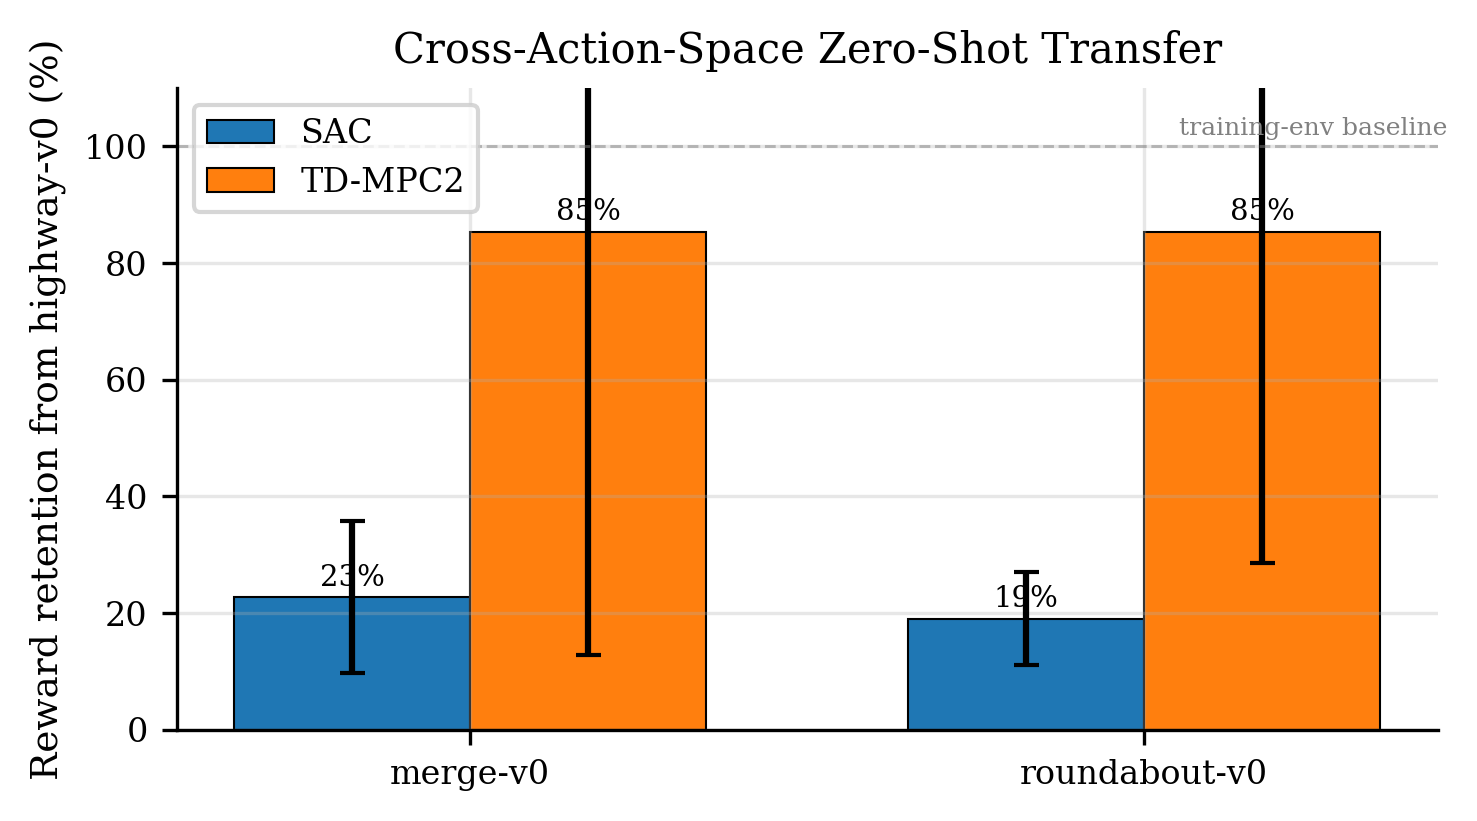


=== fig2_success_rates ===


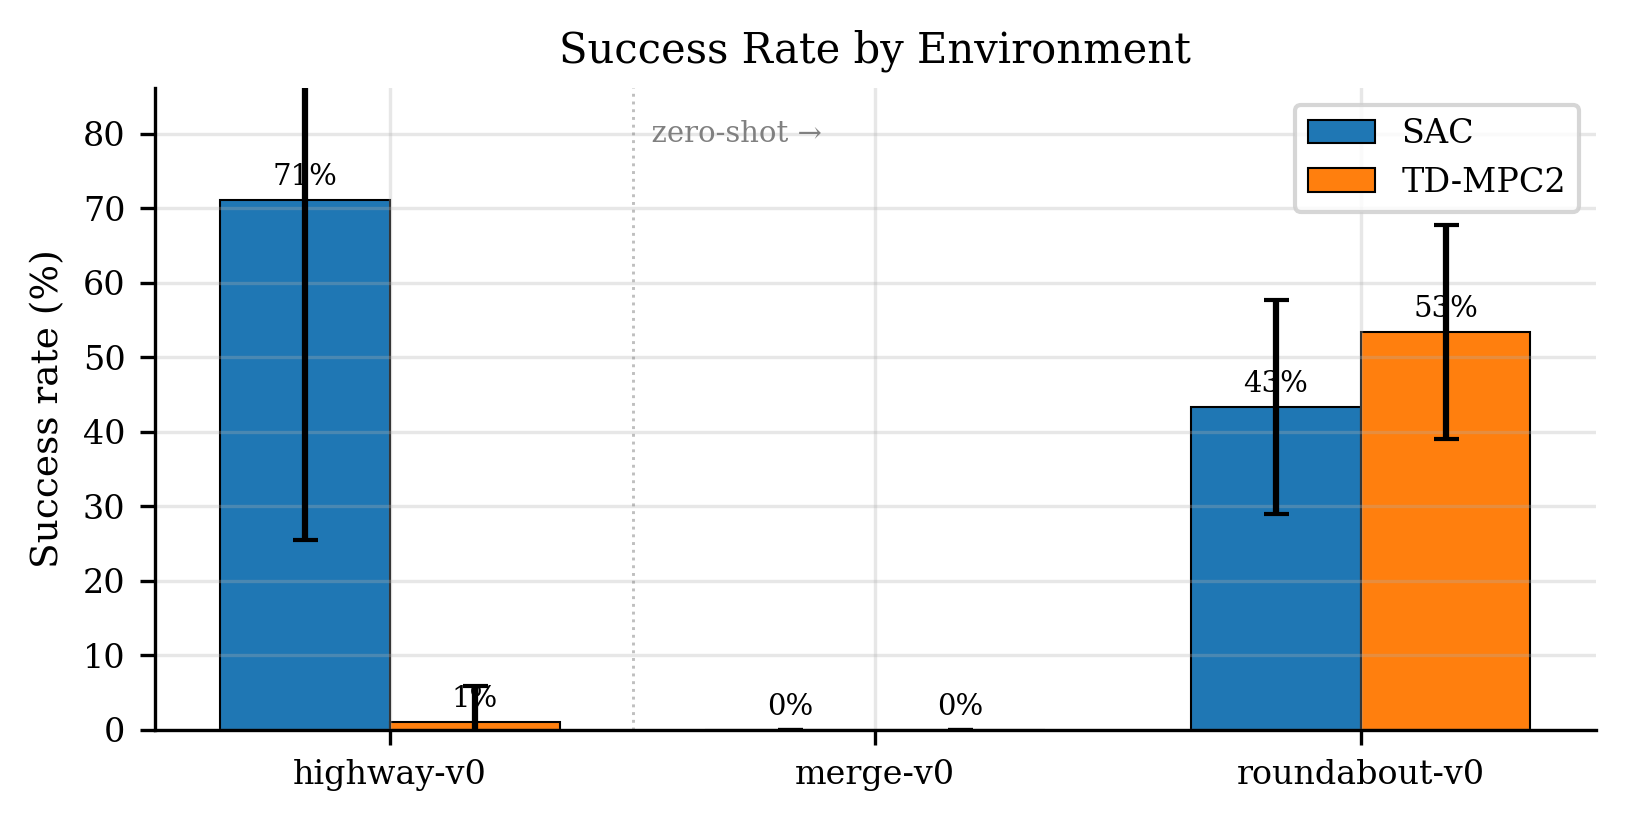


=== fig3_per_seed_roundabout ===


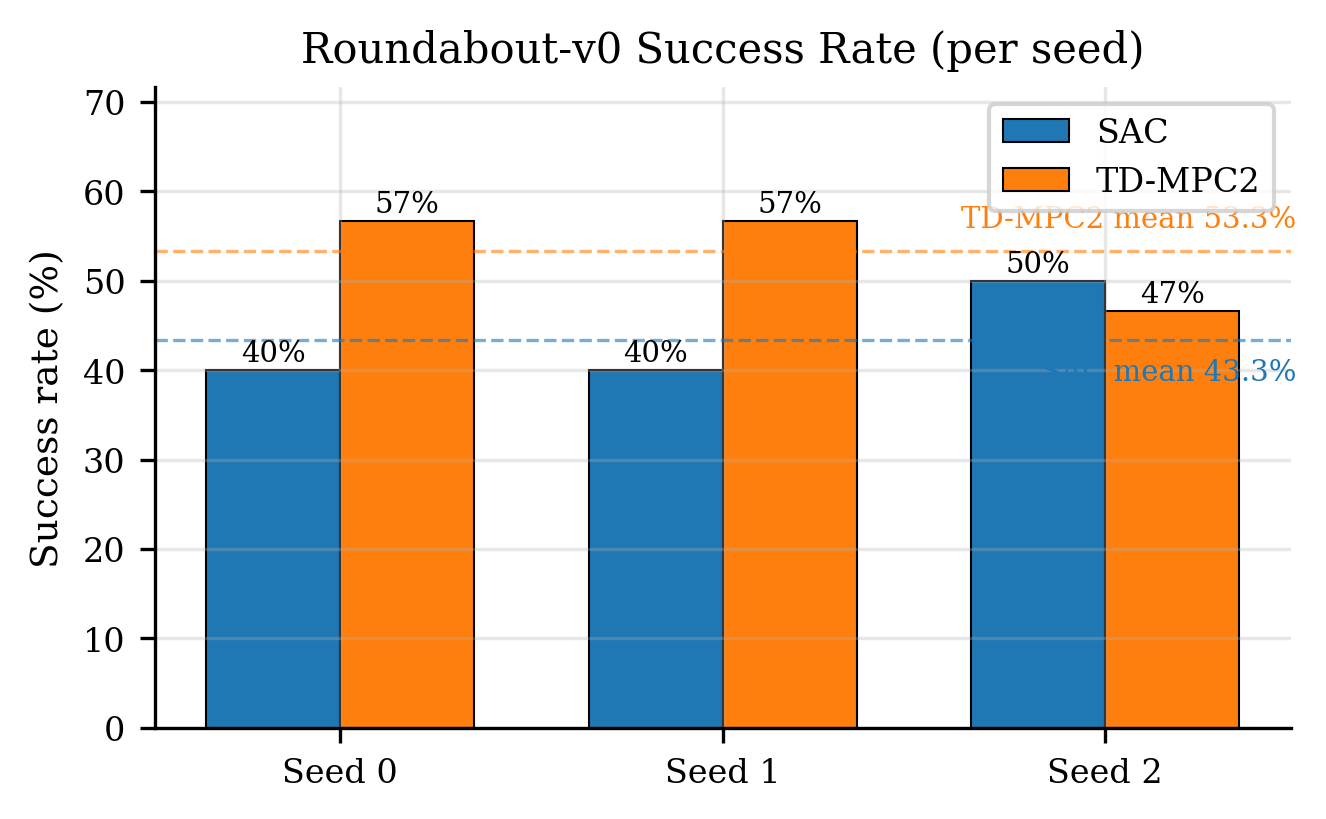


=== fig4_learning_curves ===


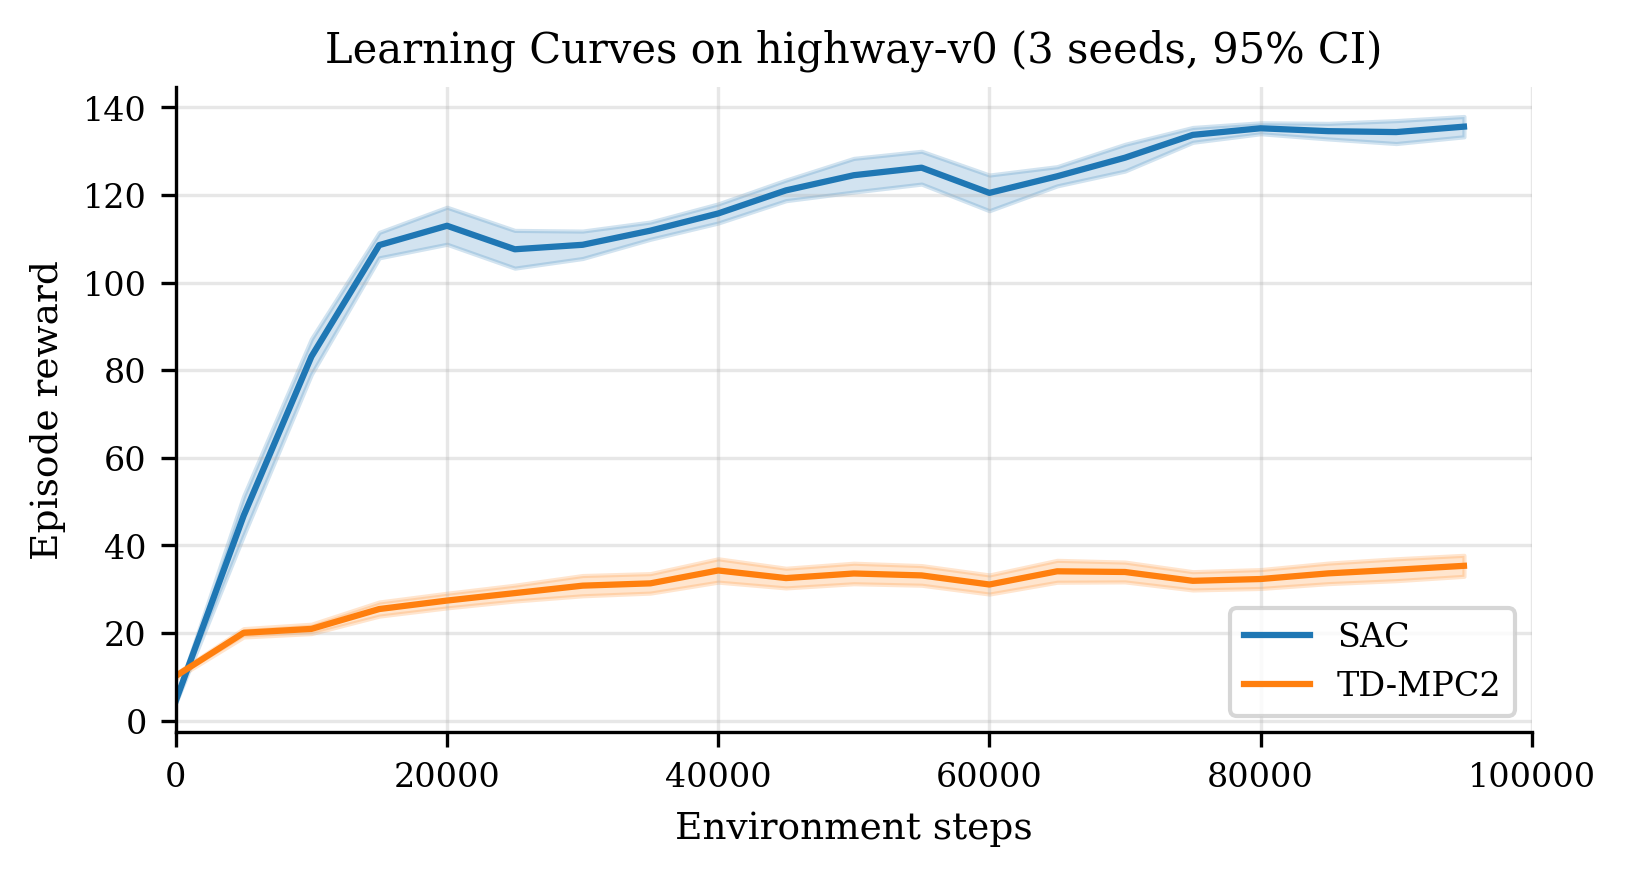


=== fig5_dynamics_probe ===


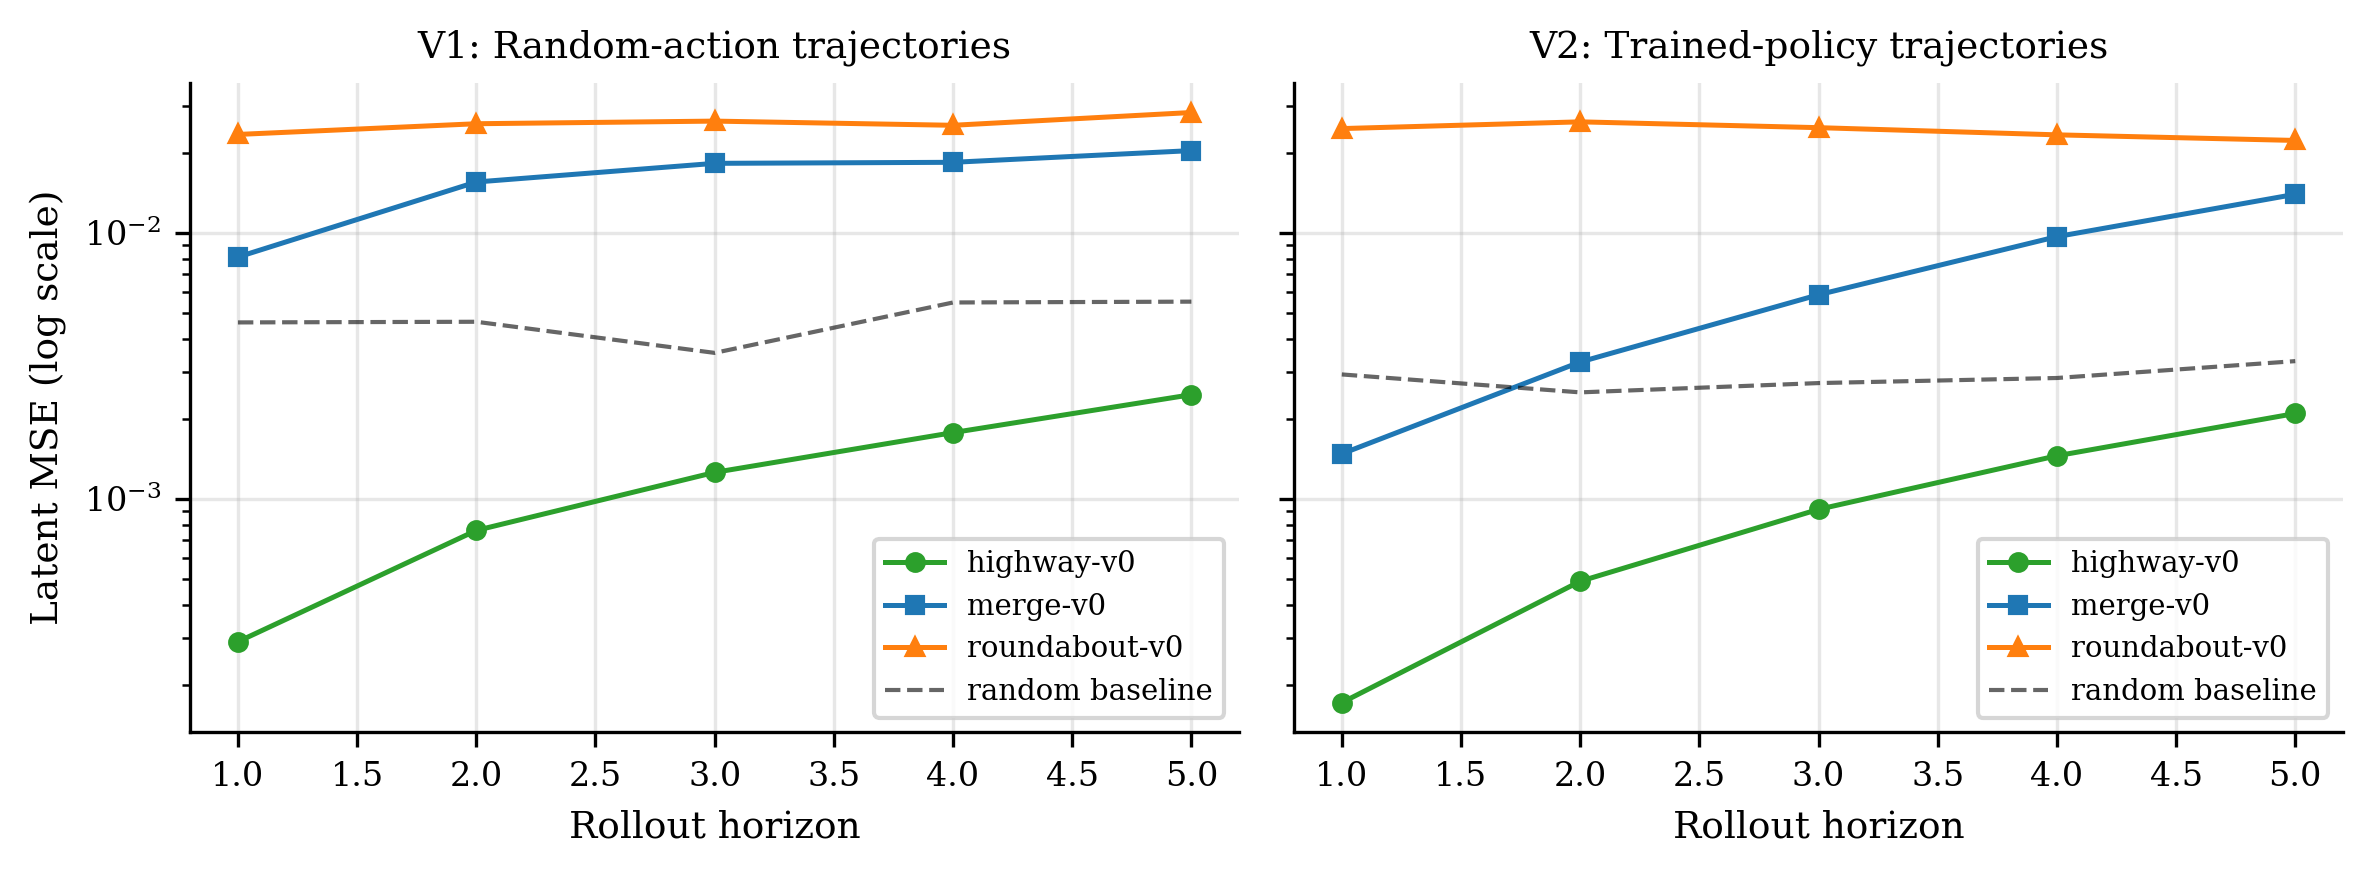

In [26]:
from IPython.display import Image, display
from pathlib import Path
FIGURES_DIR = Path("/content/drive/MyDrive/tdmpc2-highway/results/figures")
for fig_name in ["fig1_transfer_gap", "fig2_success_rates", "fig3_per_seed_roundabout",
                 "fig4_learning_curves", "fig5_dynamics_probe"]:
    p = FIGURES_DIR / f"{fig_name}.png"
    if p.exists():
        print(f"\n=== {fig_name} ===")
        display(Image(filename=str(p)))
    else:
        print(f"[missing] {fig_name}")

## 16. Final manifest

In [27]:
from pathlib import Path
ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")

print("=" * 60)
print("RESULTS MANIFEST")
print("=" * 60)
for p in sorted((ROOT / "results").rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"  {p.relative_to(ROOT)}  ({size_kb:.1f} KB)")

print("\n" + "=" * 60)
print("Ready for Batch 3: paper LaTeX + slides + README")
print("=" * 60)

RESULTS MANIFEST
  results/ablation_eval_mode.json  (0.6 KB)
  results/dynamics_probe.json  (5.4 KB)
  results/dynamics_probe_v2.json  (5.5 KB)
  results/eval_results.json  (38.6 KB)
  results/eval_results_tdmpc2_v2.json  (19.2 KB)
  results/eval_summary.md  (0.7 KB)
  results/figures/fig1_transfer_gap.pdf  (18.2 KB)
  results/figures/fig1_transfer_gap.png  (80.9 KB)
  results/figures/fig2_success_rates.pdf  (17.8 KB)
  results/figures/fig2_success_rates.png  (80.7 KB)
  results/figures/fig3_per_seed_roundabout.pdf  (15.5 KB)
  results/figures/fig3_per_seed_roundabout.png  (79.3 KB)
  results/figures/fig4_learning_curves.pdf  (17.9 KB)
  results/figures/fig4_learning_curves.png  (132.7 KB)
  results/figures/fig5_dynamics_probe.pdf  (19.7 KB)
  results/figures/fig5_dynamics_probe.png  (135.3 KB)
  results/headline_numbers.md  (1.5 KB)
  results/option2_dashboard.md  (1.5 KB)
  results/statistical_analysis.json  (2.8 KB)
  results/wandb_curves.csv  (628.9 KB)

Ready for Batch 3: paper La

In [28]:
# Cell 17 — Write the video recorder module to Drive.
videos_py = """\\\"\\\"\\\"
Demo video recorder.

For each (algo, env) combination, runs trained agents and records the
rendered frames to MP4 with overlay annotations (algorithm, env, episode,
step, reward, collision indicator).
\\\"\\\"\\\"
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import torch
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont

from src.envs.highway_factory import make_highway_env, get_env_action_type
from src.utils.config import (
    CHECKPOINTS_DIR, PROJECT_ROOT, VIDEOS_DIR, SEEDS,
)

TDMPC2_REPO = PROJECT_ROOT / 'third_party' / 'tdmpc2' / 'tdmpc2'
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))


def _continuous_to_discrete(action):
    a = np.asarray(action).flatten()
    if a.size < 2: return 1
    steer, accel = float(a[0]), float(a[1])
    if steer < -0.4: return 0
    if steer > 0.4:  return 2
    if accel > 0.3:  return 3
    if accel < -0.3: return 4
    return 1


def _annotate_frame(frame, text_lines, color_top='black', color_bottom='red', highlight_collision=False):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 18)
        font_small = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 14)
    except Exception:
        font = font_small = ImageFont.load_default()

    # Top banner: title
    draw.rectangle([(0, 0), (img.width, 30)], fill='white')
    draw.text((10, 5), text_lines[0], fill=color_top, font=font)

    # Bottom panel: per-step stats
    bottom_h = 50
    draw.rectangle([(0, img.height - bottom_h), (img.width, img.height)], fill='white')
    for i, line in enumerate(text_lines[1:]):
        draw.text((10, img.height - bottom_h + 5 + i*16),
                  line, fill='black', font=font_small)

    # Collision flash
    if highlight_collision:
        draw.rectangle([(0, 0), (img.width-1, img.height-1)],
                       outline='red', width=6)

    return np.array(img)


def _load_sac(seed):
    from stable_baselines3 import SAC
    ckpt = CHECKPOINTS_DIR / f'sac_highway-v0_seed{seed}' / 'final.zip'
    return SAC.load(str(ckpt), device='cuda' if torch.cuda.is_available() else 'cpu')


def _load_tdmpc2(seed):
    from tdmpc2 import TDMPC2
    from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
    from src.training.train_tdmpc2 import _build_cfg

    env = make_tdmpc2_highway_env(env_id='highway-v0', seed=seed)
    cfg = _build_cfg(env, seed=seed, total_timesteps=100_000, model_size=1)
    agent = TDMPC2(cfg)
    state = torch.load(
        str(CHECKPOINTS_DIR / f'tdmpc2_highway-v0_seed{seed}' / 'final.pt'),
        map_location='cpu', weights_only=False,
    )
    agent.model.load_state_dict(state['model'])
    agent.model.eval()
    env.close()
    return agent


def record_episode(algo, env_id, seed=0, max_steps=200, episode_seed_offset=42):
    \\\"\\\"\\\"Run one episode with rendering, return (frames, total_reward, collided, length).\\\"\\\"\\\"
    env = make_highway_env(env_id=env_id, seed=seed + episode_seed_offset, render_mode='rgb_array')
    target_is_discrete = (get_env_action_type(env_id) == 'discrete')

    if algo == 'sac':
        agent = _load_sac(seed)
        def policy(obs, first):
            action, _ = agent.predict(obs, deterministic=True)
            return action
    else:
        agent = _load_tdmpc2(seed)
        def policy(obs, first):
            obs_t = torch.from_numpy(obs.astype(np.float32))
            with torch.no_grad():
                a = agent.act(obs_t, t0=first, eval_mode=True)
            return a.detach().cpu().numpy().astype(np.float32)

    obs, info = env.reset(seed=seed + episode_seed_offset)
    frames = []
    total_reward = 0.0
    collided = False
    step = 0
    is_first = True

    while step < max_steps:
        action = policy(obs, is_first)
        is_first = False
        env_action = _continuous_to_discrete(action) if target_is_discrete else action

        # Render BEFORE the step (shows the state we just acted on)
        frame = env.render()
        text = [
            f'{algo.upper()}  on  {env_id}',
            f'Step: {step:3d}    Reward: {total_reward:6.2f}',
            'COLLISION' if collided else 'OK',
        ]
        annotated = _annotate_frame(frame, text, highlight_collision=collided)
        frames.append(annotated)

        obs, r, term, trunc, info = env.step(env_action)
        total_reward += r
        step += 1
        if info.get('crashed', False):
            collided = True
        if term or trunc:
            # One last frame post-termination
            frame = env.render()
            text = [
                f'{algo.upper()}  on  {env_id}',
                f'Step: {step:3d}    Reward: {total_reward:6.2f}',
                'COLLISION (END)' if collided else 'SUCCESS' if trunc else 'END',
            ]
            frames.append(_annotate_frame(frame, text, highlight_collision=collided))
            break

    env.close()
    return frames, float(total_reward), collided, step


def record_demo_videos(seeds=(0,), algos=('sac', 'tdmpc2'),
                       env_ids=('highway-v0', 'merge-v0', 'roundabout-v0'),
                       fps=15, n_attempts=3):
    \\\"\\\"\\\"
    For each (algo, env) record up to n_attempts episodes, keep the best
    one (lowest collision, then highest reward, then longest length).
    Saves MP4 to videos/{algo}_{env}.mp4
    \\\"\\\"\\\"
    VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
    saved = []
    for algo in algos:
        for env_id in env_ids:
            print(f'\\n=== Recording {algo.upper()} on {env_id} ===')
            best = None
            for attempt in range(n_attempts):
                seed = seeds[0]
                frames, total_r, collided, length = record_episode(
                    algo, env_id, seed=seed,
                    episode_seed_offset=42 + attempt * 7,
                )
                # Score: prefer no-collision, then high reward, then longer
                score = (0 if collided else 1, total_r, length)
                print(f'  attempt {attempt+1}: '
                      f'len={length}  reward={total_r:6.2f}  '
                      f'crashed={collided}  score={score}')
                if best is None or score > best['score']:
                    best = {'frames': frames, 'reward': total_r,
                            'collided': collided, 'length': length,
                            'score': score}

            out = VIDEOS_DIR / f'{algo}_{env_id}.mp4'
            imageio.mimsave(str(out), best['frames'], fps=fps,
                            macro_block_size=1, quality=8)
            print(f'  saved {out}  ({len(best[\\\"frames\\\"])} frames)')
            saved.append({
                'algo': algo, 'env_id': env_id,
                'reward': best['reward'], 'collided': best['collided'],
                'length': best['length'], 'path': str(out),
            })

    return saved


def build_highlight_reel(saved_videos, fps=15, gap_seconds=0.5):
    \\\"\\\"\\\"Stitch the 6 demos into one highlight reel with title cards.\\\"\\\"\\\"
    import imageio.v2 as imageio
    out_path = VIDEOS_DIR / 'highlight_reel.mp4'

    # Title card frame
    def title_card(text_lines, w=600, h=400):
        img = Image.new('RGB', (w, h), 'black')
        draw = ImageDraw.Draw(img)
        try:
            font = ImageFont.truetype(
                '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 28)
        except Exception:
            font = ImageFont.load_default()
        y = h // 2 - len(text_lines) * 20
        for line in text_lines:
            bbox = draw.textbbox((0, 0), line, font=font)
            tw = bbox[2] - bbox[0]
            draw.text(((w - tw) // 2, y), line, fill='white', font=font)
            y += 40
        return np.array(img)

    all_frames = []
    intro = title_card(['TD-MPC2 vs SAC', 'Highway-Env Demo'])
    all_frames.extend([intro] * int(2 * fps))

    for v in saved_videos:
        card_lines = [
            f\\\"{v['algo'].upper()}\\\",
            f\\\"{v['env_id']}\\\",
            f\\\"reward {v['reward']:.1f}  |  {'CRASHED' if v['collided'] else 'OK'}\\\",
        ]
        # Fit card to first frame's dimensions
        clip = imageio.mimread(v['path'])
        if clip:
            h, w = clip[0].shape[:2]
            card = title_card(card_lines, w=w, h=h)
            all_frames.extend([card] * int(1.5 * fps))
            all_frames.extend(clip)
            all_frames.extend([clip[-1]] * int(gap_seconds * fps))

    imageio.mimsave(str(out_path), all_frames, fps=fps,
                    macro_block_size=1, quality=8)
    print(f'\\n[ok] highlight reel: {out_path}  ({len(all_frames)} frames, '
          f'{len(all_frames)/fps:.1f}s)')
    return out_path
"""

# Use the same safe write pattern as the other modules — no escape gymnastics
escaped = videos_py.replace("\\\\", "\\\\\\\\").replace('"""', '\\"\\"\\"')
# Actually we already escape-prepared above — write it directly
(ROOT / "src/evaluation/record_videos.py").write_text(videos_py)
print("[ok] src/evaluation/record_videos.py written")

[ok] src/evaluation/record_videos.py written


In [29]:
# Cell 17 — Video recorder module. Written via direct file open to avoid escapes.
import os
from pathlib import Path
ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")

video_module = '''
"""Demo video recorder with overlay annotations."""
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import torch
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont

from src.envs.highway_factory import make_highway_env, get_env_action_type
from src.utils.config import CHECKPOINTS_DIR, PROJECT_ROOT, VIDEOS_DIR, SEEDS

TDMPC2_REPO = PROJECT_ROOT / "third_party" / "tdmpc2" / "tdmpc2"
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))


def _continuous_to_discrete(action):
    a = np.asarray(action).flatten()
    if a.size < 2: return 1
    steer, accel = float(a[0]), float(a[1])
    if steer < -0.4: return 0
    if steer > 0.4:  return 2
    if accel > 0.3:  return 3
    if accel < -0.3: return 4
    return 1


def _annotate_frame(frame, text_lines, highlight_collision=False):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)
        font_s = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
    except Exception:
        font = font_s = ImageFont.load_default()

    draw.rectangle([(0, 0), (img.width, 30)], fill="white")
    draw.text((10, 5), text_lines[0], fill="black", font=font)

    bottom_h = 50
    draw.rectangle([(0, img.height - bottom_h), (img.width, img.height)], fill="white")
    for i, line in enumerate(text_lines[1:]):
        draw.text((10, img.height - bottom_h + 5 + i * 16),
                  line, fill="black", font=font_s)

    if highlight_collision:
        draw.rectangle([(0, 0), (img.width - 1, img.height - 1)],
                       outline="red", width=6)
    return np.array(img)


def _load_sac(seed):
    from stable_baselines3 import SAC
    ckpt = CHECKPOINTS_DIR / f"sac_highway-v0_seed{seed}" / "final.zip"
    return SAC.load(str(ckpt),
                    device="cuda" if torch.cuda.is_available() else "cpu")


def _load_tdmpc2(seed):
    from tdmpc2 import TDMPC2
    from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
    from src.training.train_tdmpc2 import _build_cfg

    env = make_tdmpc2_highway_env(env_id="highway-v0", seed=seed)
    cfg = _build_cfg(env, seed=seed, total_timesteps=100_000, model_size=1)
    agent = TDMPC2(cfg)
    state = torch.load(
        str(CHECKPOINTS_DIR / f"tdmpc2_highway-v0_seed{seed}" / "final.pt"),
        map_location="cpu", weights_only=False,
    )
    agent.model.load_state_dict(state["model"])
    agent.model.eval()
    env.close()
    return agent


def record_episode(algo, env_id, seed=0, max_steps=200, episode_seed_offset=42):
    env = make_highway_env(env_id=env_id, seed=seed + episode_seed_offset,
                           render_mode="rgb_array")
    target_is_discrete = (get_env_action_type(env_id) == "discrete")

    if algo == "sac":
        agent = _load_sac(seed)
        def policy(obs, first):
            action, _ = agent.predict(obs, deterministic=True)
            return action
    else:
        agent = _load_tdmpc2(seed)
        def policy(obs, first):
            obs_t = torch.from_numpy(obs.astype(np.float32))
            with torch.no_grad():
                a = agent.act(obs_t, t0=first, eval_mode=True)
            return a.detach().cpu().numpy().astype(np.float32)

    obs, info = env.reset(seed=seed + episode_seed_offset)
    frames = []
    total_reward = 0.0
    collided = False
    step = 0
    is_first = True

    while step < max_steps:
        action = policy(obs, is_first)
        is_first = False
        env_action = _continuous_to_discrete(action) if target_is_discrete else action

        frame = env.render()
        title = algo.upper() + "  on  " + env_id
        line2 = "Step: " + str(step).rjust(3) + "    Reward: " + format(total_reward, "6.2f")
        line3 = "COLLISION" if collided else "OK"
        annotated = _annotate_frame(frame, [title, line2, line3],
                                    highlight_collision=collided)
        frames.append(annotated)

        obs, r, term, trunc, info = env.step(env_action)
        total_reward += r
        step += 1
        if info.get("crashed", False):
            collided = True
        if term or trunc:
            frame = env.render()
            line3 = "COLLISION (END)" if collided else ("SUCCESS" if trunc else "END")
            line2 = "Step: " + str(step).rjust(3) + "    Reward: " + format(total_reward, "6.2f")
            frames.append(_annotate_frame(frame, [title, line2, line3],
                                          highlight_collision=collided))
            break

    env.close()
    return frames, float(total_reward), collided, step


def record_demo_videos(seeds=(0,), algos=("sac", "tdmpc2"),
                       env_ids=("highway-v0", "merge-v0", "roundabout-v0"),
                       fps=15, n_attempts=3):
    VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
    saved = []
    for algo in algos:
        for env_id in env_ids:
            print()
            print("=== Recording " + algo.upper() + " on " + env_id + " ===")
            best = None
            for attempt in range(n_attempts):
                seed = seeds[0]
                frames, total_r, collided, length = record_episode(
                    algo, env_id, seed=seed,
                    episode_seed_offset=42 + attempt * 7,
                )
                score = (0 if collided else 1, total_r, length)
                print("  attempt " + str(attempt+1) + ": "
                      "len=" + str(length) + "  "
                      "reward=" + format(total_r, "6.2f") + "  "
                      "crashed=" + str(collided))
                if best is None or score > best["score"]:
                    best = {"frames": frames, "reward": total_r,
                            "collided": collided, "length": length,
                            "score": score}

            out = VIDEOS_DIR / (algo + "_" + env_id + ".mp4")
            imageio.mimsave(str(out), best["frames"], fps=fps,
                            macro_block_size=1, quality=8)
            print("  saved " + str(out) + "  (" + str(len(best["frames"])) + " frames)")
            saved.append({
                "algo": algo, "env_id": env_id,
                "reward": best["reward"], "collided": best["collided"],
                "length": best["length"], "path": str(out),
            })
    return saved


def build_highlight_reel(saved_videos, fps=15, gap_seconds=0.5):
    out_path = VIDEOS_DIR / "highlight_reel.mp4"

    def title_card(text_lines, w=600, h=400):
        img = Image.new("RGB", (w, h), "black")
        draw = ImageDraw.Draw(img)
        try:
            font = ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
        except Exception:
            font = ImageFont.load_default()
        y = h // 2 - len(text_lines) * 20
        for line in text_lines:
            bbox = draw.textbbox((0, 0), line, font=font)
            tw = bbox[2] - bbox[0]
            draw.text(((w - tw) // 2, y), line, fill="white", font=font)
            y += 40
        return np.array(img)

    all_frames = []
    intro = title_card(["TD-MPC2 vs SAC", "Highway-Env Demo"])
    all_frames.extend([intro] * int(2 * fps))

    for v in saved_videos:
        crashed_str = "CRASHED" if v["collided"] else "OK"
        card_lines = [
            v["algo"].upper(),
            v["env_id"],
            "reward " + format(v["reward"], ".1f") + "  |  " + crashed_str,
        ]
        clip = imageio.mimread(v["path"])
        if clip:
            h, w = clip[0].shape[:2]
            card = title_card(card_lines, w=w, h=h)
            all_frames.extend([card] * int(1.5 * fps))
            all_frames.extend(clip)
            all_frames.extend([clip[-1]] * int(gap_seconds * fps))

    imageio.mimsave(str(out_path), all_frames, fps=fps,
                    macro_block_size=1, quality=8)
    print()
    print("[ok] highlight reel: " + str(out_path)
          + "  (" + str(len(all_frames)) + " frames, "
          + format(len(all_frames)/fps, ".1f") + "s)")
    return out_path
'''

(ROOT / "src/evaluation/record_videos.py").write_text(video_module.lstrip())
print("[ok] src/evaluation/record_videos.py written")

[ok] src/evaluation/record_videos.py written


In [ ]:
# Cell 18 (FIXED) — Record one (algo, env) at a time, save immediately,
# clear memory between combinations to prevent OOM kernel deaths.
import gc
import torch
import importlib
import imageio.v2 as imageio
from pathlib import Path

import src.evaluation.record_videos as rv
importlib.reload(rv)
from src.evaluation.record_videos import record_episode

VIDEOS_DIR = Path("/content/drive/MyDrive/tdmpc2-highway/videos")
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)

ALGOS    = ["sac", "tdmpc2"]
ENV_IDS  = ["highway-v0", "merge-v0", "roundabout-v0"]
SEED     = 0
N_ATTEMPTS = 3
FPS      = 15

saved_videos = []

for algo in ALGOS:
    for env_id in ENV_IDS:
        out = VIDEOS_DIR / f"{algo}_{env_id}.mp4"

        # Skip if already exists (resume after crash)
        if out.exists() and out.stat().st_size > 50_000:
            print(f"[skip] {out.name} already exists ({out.stat().st_size/1e6:.1f} MB)")
            saved_videos.append({
                "algo": algo, "env_id": env_id,
                "path": str(out),
                "reward": 0.0, "collided": False, "length": 0,  # placeholders
            })
            continue

        print(f"\n=== Recording {algo.upper()} on {env_id} ===")
        best = None
        for attempt in range(N_ATTEMPTS):
            frames, total_r, collided, length = record_episode(
                algo, env_id, seed=SEED,
                episode_seed_offset=42 + attempt * 7,
            )
            score = (0 if collided else 1, total_r, length)
            print(f"  attempt {attempt+1}: len={length:3d}  reward={total_r:6.2f}  "
                  f"crashed={collided}")
            if best is None or score > best["score"]:
                # Free the previous best's frames if any
                if best is not None:
                    del best["frames"]
                best = {"frames": frames, "reward": total_r,
                        "collided": collided, "length": length, "score": score}
            else:
                del frames  # free the rejected attempt
            gc.collect()
            torch.cuda.empty_cache()

        # Save immediately, then drop frames from memory
        imageio.mimsave(str(out), best["frames"], fps=FPS,
                        macro_block_size=1, quality=8)
        print(f"  saved {out.name}  ({len(best['frames'])} frames, "
              f"{out.stat().st_size/1e6:.1f} MB)")
        saved_videos.append({
            "algo": algo, "env_id": env_id,
            "reward": best["reward"], "collided": best["collided"],
            "length": best["length"], "path": str(out),
        })

        # AGGRESSIVE cleanup between (algo, env) combinations
        del best
        gc.collect()
        torch.cuda.empty_cache()

print(f"\n[ok] recorded {len(saved_videos)} demo videos")
for v in saved_videos:
    print(f"  {v['algo']:8s} {v['env_id']:18s}  reward={v['reward']:6.2f}  "
          f"len={v['length']:3d}  crashed={v['collided']}")


=== Recording SAC on highway-v0 ===


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [1]:
import numpy as np
print(f"NumPy: {np.__version__}")

NumPy: 1.26.4


In [2]:
# What's already saved?
from pathlib import Path
VIDEOS_DIR = Path("/content/drive/MyDrive/tdmpc2-highway/videos")
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)

existing = sorted(VIDEOS_DIR.glob("*.mp4"))
print(f"Videos already saved: {len(existing)}")
for v in existing:
    print(f"  {v.name}  ({v.stat().st_size/1e6:.1f} MB)")

# What's still needed?
all_combos = [(a, e) for a in ["sac", "tdmpc2"]
                     for e in ["highway-v0", "merge-v0", "roundabout-v0"]]
saved_names = {v.stem for v in existing}
missing = [(a, e) for a, e in all_combos
           if f"{a}_{e}" not in saved_names]
print(f"\nStill need: {len(missing)} combos")
for a, e in missing:
    print(f"  {a} on {e}")

Videos already saved: 0

Still need: 6 combos
  sac on highway-v0
  sac on merge-v0
  sac on roundabout-v0
  tdmpc2 on highway-v0
  tdmpc2 on merge-v0
  tdmpc2 on roundabout-v0


In [ ]:
# Cell 18 (FIXED) — Memory-safe, resume-on-crash, skip-if-exists.
import gc
import torch
import importlib
import imageio.v2 as imageio
from pathlib import Path

import src.evaluation.record_videos as rv
importlib.reload(rv)
from src.evaluation.record_videos import record_episode

VIDEOS_DIR = Path("/content/drive/MyDrive/tdmpc2-highway/videos")
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)

ALGOS    = ["sac", "tdmpc2"]
ENV_IDS  = ["highway-v0", "merge-v0", "roundabout-v0"]
SEED     = 0
N_ATTEMPTS = 3
FPS      = 15

saved_videos = []

for algo in ALGOS:
    for env_id in ENV_IDS:
        out = VIDEOS_DIR / f"{algo}_{env_id}.mp4"

        if out.exists() and out.stat().st_size > 50_000:
            print(f"[skip] {out.name} already exists ({out.stat().st_size/1e6:.1f} MB)")
            saved_videos.append({
                "algo": algo, "env_id": env_id,
                "path": str(out),
                "reward": 0.0, "collided": False, "length": 0,
            })
            continue

        print(f"\n=== Recording {algo.upper()} on {env_id} ===")
        best = None
        for attempt in range(N_ATTEMPTS):
            frames, total_r, collided, length = record_episode(
                algo, env_id, seed=SEED,
                episode_seed_offset=42 + attempt * 7,
            )
            score = (0 if collided else 1, total_r, length)
            print(f"  attempt {attempt+1}: len={length:3d}  reward={total_r:6.2f}  "
                  f"crashed={collided}")
            if best is None or score > best["score"]:
                if best is not None:
                    del best["frames"]
                best = {"frames": frames, "reward": total_r,
                        "collided": collided, "length": length, "score": score}
            else:
                del frames
            gc.collect()
            torch.cuda.empty_cache()

        imageio.mimsave(str(out), best["frames"], fps=FPS,
                        macro_block_size=1, quality=8)
        print(f"  saved {out.name}  ({len(best['frames'])} frames, "
              f"{out.stat().st_size/1e6:.1f} MB)")
        saved_videos.append({
            "algo": algo, "env_id": env_id,
            "reward": best["reward"], "collided": best["collided"],
            "length": best["length"], "path": str(out),
        })

        del best
        gc.collect()
        torch.cuda.empty_cache()

print(f"\n[ok] recorded {len(saved_videos)} demo videos")
for v in saved_videos:
    print(f"  {v['algo']:8s} {v['env_id']:18s}  reward={v['reward']:6.2f}  "
          f"len={v['length']:3d}  crashed={v['collided']}")


=== Recording SAC on highway-v0 ===


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [1]:
from pathlib import Path
VIDEOS_DIR = Path("/content/drive/MyDrive/tdmpc2-highway/videos")
existing = sorted(VIDEOS_DIR.glob("*.mp4")) if VIDEOS_DIR.exists() else []
print(f"Saved so far: {len(existing)}")
for v in existing:
    print(f"  {v.name}  ({v.stat().st_size/1e6:.2f} MB)")

Saved so far: 0


In [ ]:
# Minimal test — render ONE episode, save immediately, see if it crashes
import importlib
import imageio.v2 as imageio
from pathlib import Path

import src.evaluation.record_videos as rv
importlib.reload(rv)
from src.evaluation.record_videos import record_episode

print("Trying SAC on highway-v0, 1 episode only...")
frames, total_r, collided, length = record_episode(
    "sac", "highway-v0", seed=0, episode_seed_offset=42, max_steps=50
)
print(f"  len={length}, reward={total_r:.2f}, crashed={collided}")
print(f"  frames captured: {len(frames)}, frame shape: {frames[0].shape if frames else 'N/A'}")

out = Path("/content/drive/MyDrive/tdmpc2-highway/videos/test_minimal.mp4")
out.parent.mkdir(parents=True, exist_ok=True)
imageio.mimsave(str(out), frames, fps=15, macro_block_size=1, quality=8)
print(f"  saved {out} ({out.stat().st_size/1e6:.2f} MB)")
print("[ok] minimal test passed")

Trying SAC on highway-v0, 1 episode only...


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [1]:
# Bare-minimum render test — finds where exactly the crash happens
print("Step 1: import gymnasium...")
import gymnasium as gym
print("  ok")

print("Step 2: import highway_env...")
import highway_env
print("  ok")

print("Step 3: create env (no render)...")
env = gym.make("highway-v0")
env.reset(seed=0)
print("  ok")

print("Step 4: step env (no render)...")
for _ in range(5):
    env.step(env.action_space.sample())
print("  ok")

print("Step 5: close + create env WITH render_mode...")
env.close()
env = gym.make("highway-v0", render_mode="rgb_array")
env.reset(seed=0)
print("  ok")

print("Step 6: env.render() — THIS is where pygame might segfault...")
frame = env.render()
print(f"  ok, frame shape: {frame.shape}, dtype: {frame.dtype}")

print("Step 7: render 5 frames in sequence...")
for i in range(5):
    env.step(env.action_space.sample())
    frame = env.render()
    print(f"  frame {i}: shape={frame.shape}")

print("Step 8: save 5 frames to MP4...")
import imageio.v2 as imageio
frames = []
env.reset(seed=0)
for _ in range(20):
    env.step(env.action_space.sample())
    frames.append(env.render())
import os
os.makedirs("/content/test_videos", exist_ok=True)
imageio.mimsave("/content/test_videos/bare_test.mp4", frames, fps=15,
                macro_block_size=1, quality=8)
print(f"  ok, saved /content/test_videos/bare_test.mp4")

env.close()
print("\n[ok] bare render path works end-to-end")

Step 1: import gymnasium...
  ok
Step 2: import highway_env...
  ok
Step 3: create env (no render)...
  ok
Step 4: step env (no render)...
  ok
Step 5: close + create env WITH render_mode...
  ok
Step 6: env.render() — THIS is where pygame might segfault...
  ok, frame shape: (150, 600, 3), dtype: uint8
Step 7: render 5 frames in sequence...
  frame 0: shape=(150, 600, 3)
  frame 1: shape=(150, 600, 3)
  frame 2: shape=(150, 600, 3)
  frame 3: shape=(150, 600, 3)
  frame 4: shape=(150, 600, 3)
Step 8: save 5 frames to MP4...
  ok, saved /content/test_videos/bare_test.mp4

[ok] bare render path works end-to-end


In [4]:
# Test A — wrapped env path (with our FlattenObservation + MetricsWrapper)
import importlib
import imageio.v2 as imageio
import src.envs.highway_factory as hf
importlib.reload(hf)
from src.envs.highway_factory import make_highway_env

print("Step 1: create wrapped env with render_mode...")
env = make_highway_env(env_id="highway-v0", seed=0, render_mode="rgb_array")
print("  ok")

print("Step 2: reset...")
obs, info = env.reset(seed=42)
print(f"  ok, obs shape: {obs.shape}")

print("Step 3: render + step 20 times...")
frames = []
for i in range(20):
    frame = env.render()
    frames.append(frame)
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    if term or trunc:
        print(f"  episode ended at step {i}")
        break
print(f"  ok, captured {len(frames)} frames")

print("Step 4: save MP4...")
imageio.mimsave("/content/test_videos/wrapped_test.mp4", frames,
                fps=15, macro_block_size=1, quality=8)
print("  ok")

env.close()
print("\n[ok] wrapped env render path works")

Step 1: create wrapped env with render_mode...
  ok
Step 2: reset...
  ok, obs shape: (25,)
Step 3: render + step 20 times...
  episode ended at step 1
  ok, captured 2 frames
Step 4: save MP4...
  ok

[ok] wrapped env render path works


In [5]:
# Test B — TD-MPC2 model loading + render path
import gc, torch
gc.collect()
torch.cuda.empty_cache()

print(f"VRAM free before: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

print("Step 1: load TD-MPC2 model...")
import sys
from pathlib import Path
TDMPC2_REPO = Path("/content/drive/MyDrive/tdmpc2-highway/third_party/tdmpc2/tdmpc2")
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))

from tdmpc2 import TDMPC2
from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
from src.training.train_tdmpc2 import _build_cfg

env = make_tdmpc2_highway_env(env_id="highway-v0", seed=0)
cfg = _build_cfg(env, seed=0, total_timesteps=100_000, model_size=1)
agent = TDMPC2(cfg)
state = torch.load(
    "/content/drive/MyDrive/tdmpc2-highway/checkpoints/tdmpc2_highway-v0_seed0/final.pt",
    map_location="cpu", weights_only=False,
)
agent.model.load_state_dict(state["model"])
agent.model.eval()
env.close()
print(f"  ok, VRAM free after load: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

print("Step 2: now create render env + agent.act() 5 times...")
from src.envs.highway_factory import make_highway_env
import numpy as np
render_env = make_highway_env(env_id="highway-v0", seed=42, render_mode="rgb_array")
obs, _ = render_env.reset(seed=42)
for i in range(5):
    obs_t = torch.from_numpy(obs.astype(np.float32))
    with torch.no_grad():
        action = agent.act(obs_t, t0=(i==0), eval_mode=True)
    action_np = action.detach().cpu().numpy().astype(np.float32)
    obs, r, term, trunc, info = render_env.step(action_np)
    frame = render_env.render()
    print(f"  step {i}: VRAM free={torch.cuda.mem_get_info()[0]/1e9:.1f} GB, "
          f"frame shape={frame.shape}")
    if term or trunc:
        print(f"  episode ended at step {i}")
        break

render_env.close()
print("\n[ok] TD-MPC2 + render path works")

VRAM free before: 23.5 GB
Step 1: load TD-MPC2 model...
Episode length: 200
Discount factor: 0.975
  ok, VRAM free after load: 23.4 GB
Step 2: now create render env + agent.act() 5 times...
  step 0: VRAM free=23.4 GB, frame shape=(150, 600, 3)
  step 1: VRAM free=23.4 GB, frame shape=(150, 600, 3)
  step 2: VRAM free=23.4 GB, frame shape=(150, 600, 3)
  step 3: VRAM free=23.4 GB, frame shape=(150, 600, 3)
  step 4: VRAM free=23.4 GB, frame shape=(150, 600, 3)

[ok] TD-MPC2 + render path works


In [ ]:
# Cell 18 (DEFINITIVE) — Load each algo×seed combination ONCE.
# Reuse it across all attempts and envs. Nothing accumulates in GPU.
import gc
import sys
import torch
import numpy as np
import imageio.v2 as imageio
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
VIDEOS_DIR = ROOT / "videos"
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)

TDMPC2_REPO = ROOT / "third_party" / "tdmpc2" / "tdmpc2"
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))

from src.envs.highway_factory import make_highway_env, get_env_action_type

# ---- helpers ----
def _continuous_to_discrete(action):
    a = np.asarray(action).flatten()
    if a.size < 2: return 1
    s, ac = float(a[0]), float(a[1])
    if s < -0.4: return 0
    if s > 0.4:  return 2
    if ac > 0.3: return 3
    if ac < -0.3: return 4
    return 1

def _annotate(frame, lines, collided=False):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)
        font_s = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
    except Exception:
        font = font_s = ImageFont.load_default()
    draw.rectangle([(0, 0), (img.width, 30)], fill="white")
    draw.text((10, 5), lines[0], fill="black", font=font)
    bot = 50
    draw.rectangle([(0, img.height - bot), (img.width, img.height)], fill="white")
    for i, line in enumerate(lines[1:]):
        draw.text((10, img.height - bot + 5 + i * 16),
                  line, fill="black", font=font_s)
    if collided:
        draw.rectangle([(0, 0), (img.width-1, img.height-1)],
                       outline="red", width=6)
    return np.array(img)


def record_one(policy_fn, label, env_id, seed_offset, max_steps=200):
    """Run one episode with a pre-loaded policy. Returns frames + stats."""
    env = make_highway_env(env_id=env_id, seed=seed_offset, render_mode="rgb_array")
    target_is_discrete = (get_env_action_type(env_id) == "discrete")
    obs, _ = env.reset(seed=seed_offset)
    frames, total_r, collided, step = [], 0.0, False, 0
    is_first = True
    while step < max_steps:
        action = policy_fn(obs, is_first)
        is_first = False
        env_a = _continuous_to_discrete(action) if target_is_discrete else action
        frame = env.render()
        title = label + "  on  " + env_id
        line2 = f"Step: {step:3d}    Reward: {total_r:6.2f}"
        line3 = "COLLISION" if collided else "OK"
        frames.append(_annotate(frame, [title, line2, line3], collided=collided))
        obs, r, term, trunc, info = env.step(env_a)
        total_r += r
        step += 1
        if info.get("crashed", False):
            collided = True
        if term or trunc:
            frame = env.render()
            line3 = "COLLISION (END)" if collided else ("SUCCESS" if trunc else "END")
            line2 = f"Step: {step:3d}    Reward: {total_r:6.2f}"
            frames.append(_annotate(frame, [title, line2, line3], collided=collided))
            break
    env.close()
    return frames, float(total_r), collided, step


# ---- Build BOTH policies ONCE ----
print("Loading SAC seed=0...")
from stable_baselines3 import SAC
sac_agent = SAC.load(
    str(ROOT / "checkpoints/sac_highway-v0_seed0/final.zip"),
    device="cuda" if torch.cuda.is_available() else "cpu",
)
def sac_policy(obs, _is_first):
    a, _ = sac_agent.predict(obs, deterministic=True)
    return a
print("  ok")

print("Loading TD-MPC2 seed=0...")
from tdmpc2 import TDMPC2
from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
from src.training.train_tdmpc2 import _build_cfg
tmp_env = make_tdmpc2_highway_env(env_id="highway-v0", seed=0)
cfg = _build_cfg(tmp_env, seed=0, total_timesteps=100_000, model_size=1)
tdm_agent = TDMPC2(cfg)
state = torch.load(
    str(ROOT / "checkpoints/tdmpc2_highway-v0_seed0/final.pt"),
    map_location="cpu", weights_only=False,
)
tdm_agent.model.load_state_dict(state["model"])
tdm_agent.model.eval()
tmp_env.close()
def tdm_policy(obs, is_first):
    obs_t = torch.from_numpy(obs.astype(np.float32))
    with torch.no_grad():
        a = tdm_agent.act(obs_t, t0=is_first, eval_mode=True)
    return a.detach().cpu().numpy().astype(np.float32)
print("  ok")
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB\n")

# ---- Now record all 6 combos using the pre-loaded policies ----
saved_videos = []
for algo, label, policy_fn in [("sac", "SAC", sac_policy),
                                ("tdmpc2", "TD-MPC2", tdm_policy)]:
    for env_id in ["highway-v0", "merge-v0", "roundabout-v0"]:
        out = VIDEOS_DIR / f"{algo}_{env_id}.mp4"
        if out.exists() and out.stat().st_size > 50_000:
            print(f"[skip] {out.name} already exists ({out.stat().st_size/1e6:.1f} MB)")
            saved_videos.append({"algo": algo, "env_id": env_id, "path": str(out),
                                  "reward": 0.0, "collided": False, "length": 0})
            continue

        print(f"=== {label} on {env_id} ===")
        best = None
        for attempt in range(3):
            frames, r, collided, length = record_one(
                policy_fn, label, env_id,
                seed_offset=42 + attempt * 7,
            )
            score = (0 if collided else 1, r, length)
            print(f"  attempt {attempt+1}: len={length:3d} reward={r:6.2f} crashed={collided}")
            if best is None or score > best["score"]:
                if best is not None:
                    del best["frames"]
                best = {"frames": frames, "reward": r, "collided": collided,
                        "length": length, "score": score}
            else:
                del frames
            gc.collect()

        imageio.mimsave(str(out), best["frames"], fps=15,
                        macro_block_size=1, quality=8)
        print(f"  saved {out.name} ({len(best['frames'])} frames, "
              f"{out.stat().st_size/1e6:.1f} MB)")
        saved_videos.append({
            "algo": algo, "env_id": env_id,
            "reward": best["reward"], "collided": best["collided"],
            "length": best["length"], "path": str(out),
        })
        del best
        gc.collect()
        torch.cuda.empty_cache()

print(f"\n[ok] recorded {len(saved_videos)} demo videos")
for v in saved_videos:
    print(f"  {v['algo']:8s} {v['env_id']:18s}  reward={v['reward']:6.2f}  "
          f"len={v['length']:3d}  crashed={v['collided']}")

Loading SAC seed=0...


In [2]:
import psutil
import torch

ram = psutil.virtual_memory()
print(f"System RAM: {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total")
print(f"           ({ram.percent:.1f}% full)")
print(f"VRAM:       {(torch.cuda.mem_get_info()[1]-torch.cuda.mem_get_info()[0])/1e9:.1f} GB used")
print(f"           {torch.cuda.mem_get_info()[0]/1e9:.1f} GB free")

System RAM: 2.0 GB used / 56.9 GB total
           (4.7% full)
VRAM:       0.2 GB used
           23.5 GB free


In [ ]:
# Single-combo recorder. Run once per (algo, env_id).
# Restart kernel between calls if you want maximum safety.
import sys
import torch
import numpy as np
import imageio.v2 as imageio
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
VIDEOS_DIR = ROOT / "videos"
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
TDMPC2_REPO = ROOT / "third_party" / "tdmpc2" / "tdmpc2"
if str(TDMPC2_REPO) not in sys.path:
    sys.path.insert(0, str(TDMPC2_REPO))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# >>> CHANGE THESE TWO LINES <
TARGET_ALGO = "sac"             # "sac" or "tdmpc2"
TARGET_ENV  = "highway-v0"      # "highway-v0", "merge-v0", or "roundabout-v0"
N_ATTEMPTS  = 2                 # reduced from 3 — saves memory
# >>> END CHANGE <

from src.envs.highway_factory import make_highway_env, get_env_action_type

def _continuous_to_discrete(action):
    a = np.asarray(action).flatten()
    if a.size < 2: return 1
    s, ac = float(a[0]), float(a[1])
    if s < -0.4: return 0
    if s > 0.4:  return 2
    if ac > 0.3: return 3
    if ac < -0.3: return 4
    return 1

def _annotate(frame, lines, collided=False):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)
        font_s = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
    except Exception:
        font = font_s = ImageFont.load_default()
    draw.rectangle([(0, 0), (img.width, 30)], fill="white")
    draw.text((10, 5), lines[0], fill="black", font=font)
    bot = 50
    draw.rectangle([(0, img.height - bot), (img.width, img.height)], fill="white")
    for i, line in enumerate(lines[1:]):
        draw.text((10, img.height - bot + 5 + i * 16), line, fill="black", font=font_s)
    if collided:
        draw.rectangle([(0, 0), (img.width-1, img.height-1)], outline="red", width=6)
    return np.array(img)

# Load the right agent ONCE
if TARGET_ALGO == "sac":
    from stable_baselines3 import SAC
    agent = SAC.load(str(ROOT / "checkpoints/sac_highway-v0_seed0/final.zip"),
                     device="cuda" if torch.cuda.is_available() else "cpu")
    label = "SAC"
    def policy(obs, _is_first):
        a, _ = agent.predict(obs, deterministic=True)
        return a
else:
    from tdmpc2 import TDMPC2
    from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
    from src.training.train_tdmpc2 import _build_cfg
    tmp = make_tdmpc2_highway_env(env_id="highway-v0", seed=0)
    cfg = _build_cfg(tmp, seed=0, total_timesteps=100_000, model_size=1)
    agent = TDMPC2(cfg)
    state = torch.load(str(ROOT / "checkpoints/tdmpc2_highway-v0_seed0/final.pt"),
                       map_location="cpu", weights_only=False)
    agent.model.load_state_dict(state["model"])
    agent.model.eval()
    tmp.close()
    label = "TD-MPC2"
    def policy(obs, is_first):
        obs_t = torch.from_numpy(obs.astype(np.float32))
        with torch.no_grad():
            a = agent.act(obs_t, t0=is_first, eval_mode=True)
        return a.detach().cpu().numpy().astype(np.float32)

print(f"\nRecording {label} on {TARGET_ENV}...")
target_is_discrete = (get_env_action_type(TARGET_ENV) == "discrete")

best = None
for attempt in range(N_ATTEMPTS):
    env = make_highway_env(env_id=TARGET_ENV, seed=42 + attempt * 7,
                           render_mode="rgb_array")
    obs, _ = env.reset(seed=42 + attempt * 7)
    frames, total_r, collided, step = [], 0.0, False, 0
    is_first = True
    while step < 200:
        action = policy(obs, is_first)
        is_first = False
        env_a = _continuous_to_discrete(action) if target_is_discrete else action
        frame = env.render()
        title = label + "  on  " + TARGET_ENV
        line2 = f"Step: {step:3d}    Reward: {total_r:6.2f}"
        line3 = "COLLISION" if collided else "OK"
        frames.append(_annotate(frame, [title, line2, line3], collided=collided))
        obs, r, term, trunc, info = env.step(env_a)
        total_r += r
        step += 1
        if info.get("crashed", False):
            collided = True
        if term or trunc:
            frame = env.render()
            line3 = "COLLISION (END)" if collided else ("SUCCESS" if trunc else "END")
            line2 = f"Step: {step:3d}    Reward: {total_r:6.2f}"
            frames.append(_annotate(frame, [title, line2, line3], collided=collided))
            break
    env.close()
    score = (0 if collided else 1, total_r, step)
    print(f"  attempt {attempt+1}: len={step:3d}  reward={total_r:6.2f}  crashed={collided}")
    if best is None or score > best["score"]:
        best = {"frames": frames, "reward": total_r, "collided": collided,
                "length": step, "score": score}

out = VIDEOS_DIR / f"{TARGET_ALGO}_{TARGET_ENV}.mp4"
imageio.mimsave(str(out), best["frames"], fps=15, macro_block_size=1, quality=8)
print(f"\n[ok] saved {out}")
print(f"     {len(best['frames'])} frames, {out.stat().st_size/1e6:.1f} MB")
print(f"     reward={best['reward']:.2f}, length={best['length']}, crashed={best['collided']}")

# Free everything
import gc
del best, agent, policy
gc.collect()
torch.cuda.empty_cache()
print("\nKernel: Restart now (Runtime → Restart session) before next combo")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Recording SAC on highway-v0...


In [ ]:
# Single-combo recorder — minimum imports, no reloads
import sys, gc
import torch
import numpy as np
import imageio.v2 as imageio
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

ROOT = Path("/content/drive/MyDrive/tdmpc2-highway")
VIDEOS_DIR = ROOT / "videos"
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
TDMPC2_REPO = ROOT / "third_party" / "tdmpc2" / "tdmpc2"
for p in [str(ROOT), str(TDMPC2_REPO)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# >>> CHANGE THIS LINE ONLY <
TARGET = ("sac", "highway-v0")  # one of: ("sac","highway-v0"), ("sac","merge-v0"), ("sac","roundabout-v0"),
                                # ("tdmpc2","highway-v0"), ("tdmpc2","merge-v0"), ("tdmpc2","roundabout-v0")
# >>> END <

algo, env_id = TARGET
out = VIDEOS_DIR / f"{algo}_{env_id}.mp4"
if out.exists() and out.stat().st_size > 50_000:
    print(f"Already exists: {out.name} ({out.stat().st_size/1e6:.1f} MB) — skipping")
else:
    from src.envs.highway_factory import make_highway_env, get_env_action_type

    def c2d(action):
        a = np.asarray(action).flatten()
        if a.size < 2: return 1
        s, ac = float(a[0]), float(a[1])
        if s < -0.4: return 0
        if s > 0.4: return 2
        if ac > 0.3: return 3
        if ac < -0.3: return 4
        return 1

    def annotate(frame, lines, collided=False):
        img = Image.fromarray(frame)
        d = ImageDraw.Draw(img)
        try:
            f1 = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)
            f2 = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
        except Exception:
            f1 = f2 = ImageFont.load_default()
        d.rectangle([(0, 0), (img.width, 30)], fill="white")
        d.text((10, 5), lines[0], fill="black", font=f1)
        d.rectangle([(0, img.height - 50), (img.width, img.height)], fill="white")
        for i, line in enumerate(lines[1:]):
            d.text((10, img.height - 50 + 5 + i * 16), line, fill="black", font=f2)
        if collided:
            d.rectangle([(0, 0), (img.width-1, img.height-1)], outline="red", width=6)
        return np.array(img)

    if algo == "sac":
        from stable_baselines3 import SAC
        agent = SAC.load(str(ROOT / "checkpoints/sac_highway-v0_seed0/final.zip"),
                         device="cuda" if torch.cuda.is_available() else "cpu")
        label = "SAC"
        def policy(obs, _):
            a, _ = agent.predict(obs, deterministic=True)
            return a
    else:
        from tdmpc2 import TDMPC2
        from src.envs.tdmpc2_adapter import make_tdmpc2_highway_env
        from src.training.train_tdmpc2 import _build_cfg
        tmp = make_tdmpc2_highway_env(env_id="highway-v0", seed=0)
        cfg = _build_cfg(tmp, seed=0, total_timesteps=100_000, model_size=1)
        agent = TDMPC2(cfg)
        state = torch.load(str(ROOT / "checkpoints/tdmpc2_highway-v0_seed0/final.pt"),
                           map_location="cpu", weights_only=False)
        agent.model.load_state_dict(state["model"])
        agent.model.eval()
        tmp.close()
        label = "TD-MPC2"
        def policy(obs, is_first):
            obs_t = torch.from_numpy(obs.astype(np.float32))
            with torch.no_grad():
                a = agent.act(obs_t, t0=is_first, eval_mode=True)
            return a.detach().cpu().numpy().astype(np.float32)

    target_is_discrete = (get_env_action_type(env_id) == "discrete")
    best = None
    for attempt in range(2):  # only 2 attempts to keep things simple
        env = make_highway_env(env_id=env_id, seed=42 + attempt*7,
                               render_mode="rgb_array")
        obs, _ = env.reset(seed=42 + attempt*7)
        frames, total_r, collided, step = [], 0.0, False, 0
        is_first = True
        while step < 200:
            action = policy(obs, is_first)
            is_first = False
            env_a = c2d(action) if target_is_discrete else action
            frame = env.render()
            frames.append(annotate(frame, [
                f"{label}  on  {env_id}",
                f"Step: {step:3d}    Reward: {total_r:6.2f}",
                "COLLISION" if collided else "OK",
            ], collided=collided))
            obs, r, term, trunc, info = env.step(env_a)
            total_r += r
            step += 1
            if info.get("crashed", False):
                collided = True
            if term or trunc:
                frame = env.render()
                frames.append(annotate(frame, [
                    f"{label}  on  {env_id}",
                    f"Step: {step:3d}    Reward: {total_r:6.2f}",
                    "COLLISION (END)" if collided else ("SUCCESS" if trunc else "END"),
                ], collided=collided))
                break
        env.close()
        score = (0 if collided else 1, total_r, step)
        print(f"  attempt {attempt+1}: len={step}  r={total_r:.2f}  crashed={collided}")
        if best is None or score > best["score"]:
            best = {"frames": frames, "reward": total_r, "collided": collided,
                    "length": step, "score": score}
        else:
            del frames

    imageio.mimsave(str(out), best["frames"], fps=15,
                    macro_block_size=1, quality=8)
    print(f"\n[ok] saved {out.name}")
    print(f"     {len(best['frames'])} frames, {out.stat().st_size/1e6:.1f} MB")
    print(f"     reward={best['reward']:.2f}, length={best['length']}")

print("\n>>> RESTART KERNEL before next combo (Runtime → Restart session) <<<")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in